# Hydro Data Projections

This tutorial demonstrates advanced projection techniques for hydrodynamical simulation data using MERA.jl. Learn how to create 2D projections from 3D data, handle different coordinate systems, and visualize complex astrophysical datasets.

## Quick Reference

### Essential Functions
```julia
# Basic projection
projection(data, :variable, :unit)

# Multi-quantity projection  
projection(data, [:var1, :var2], units=[:unit1, :unit2])

# Spatial selection
projection(data, :sd, :Msol_pc2, 
          xrange=[-10,10], center=[:boxcenter], range_unit=:kpc)

# Direction control
projection(data, :sd, :Msol_pc2, direction=:x)  # x, y, z directions

# Resolution control
projection(data, :sd, :Msol_pc2, lmax=8)        # AMR level
projection(data, :sd, :Msol_pc2, res=256)       # Effective grid resolution  
projection(data, :sd, :Msol_pc2, pxsize=[100.,:pc])  # Physical pixel size

# Masking and weighting
projection(data, :sd, :Msol_pc2, mask=mask_array)
projection(data, :rho, :g_cm3, weighting=[:volume])
```

### Key Projection Quantities
- **`:sd`** - Surface density (Σ) 
- **`:vx, :vy, :vz`** - Velocity components
- **`:v`** - Total velocity magnitude
- **`:σ, :σx, :σy, :σz`** - Velocity dispersions
- **`:cs`** - Sound speed
- **`:r_cylinder, :vr_cylinder, :vϕ_cylinder`** 
- **`:ϕ, :σr_cylinder, :σϕ_cylinder`** 

## Overview

MERA.jl provides powerful projection capabilities for analyzing hydrodynamical simulations:
- **Surface density projections** in arbitrary directions
- **Kinematic analysis** with velocity fields and dispersions
- **Multi-quantity projections** with customizable units
- **Coordinate system transformations** (Cartesian, cylindrical, spherical)
- **Advanced masking and filtering** for targeted analysis

## Key Concepts

- **Projection Direction**: Control viewing angle (x, y, z directions)
- **Grid Resolution**: Customize output resolution via `lmax`, `res`, or `pxsize`
- **Weighting Schemes**: Mass-weighted, volume-weighted, or custom weighting
- **Coordinate Systems**: Native Cartesian or derived cylindrical/spherical coordinates

### Intensive vs. extensive quantities — what a projection *means*

A line-of-sight projection reduces a 3-D field to a 2-D map, and **how** the cells along each
sightline are combined depends on whether the quantity is *intensive* or *extensive*:

| Quantity kind | Examples | How it is projected | Result per pixel |
|---|---|---|---|
| **Extensive** (adds up) | `:sd` (surface density), `:mass` | **summed** along the sightline, divided by the pixel area | a column / surface density — the total is conserved |
| **Intensive** (a local value) | `:T`, `:vx`, `:rho`, `:cs`, `:p`, … | **weight-averaged** along the sightline (`weighting=:mass` by default, or `:volume`) | a representative value, *not* a sum |

In other words: a mass-weighted projection of an intensive field answers *"what value would a
mass-tracer see, averaged down this column?"*, while a surface-density projection answers
*"how much is there per unit area?"*. Choosing the wrong combination is the most common projection
mistake — e.g. mass-weighting a temperature map biases it toward dense gas, whereas volume-weighting
(`weighting=:volume`) gives the volume-filling temperature.

```julia
projection(gas, :T)                      # mass-weighted T (default) — tracks dense gas
projection(gas, :T,  weighting=:volume)  # volume-weighted T — volume-filling value
projection(gas, :sd, :Msol_pc2)          # extensive: summed mass per pixel area (column)
```

!!! note "`mode=:standard` vs `mode=:sum`"
    The default `mode=:standard` produces the **physically normalized** map described above
    (extensive ⇒ per-area column; intensive ⇒ weight-average). `mode=:sum` instead returns the
    **raw per-pixel weighted sum** with no area/normalization division — useful when you want to
    accumulate a conserved total yourself (e.g. summing energy or a custom budget across pixels) and
    will apply your own normalization. For standard surface-density and weighted-average maps, keep
    `mode=:standard`. (Particle projections support `weighting=:mass`/`:volume`; `mode` applies to
    the hydro/gravity grid path.)

## Environment Setup and Data Loading

### Package Configuration

First, we configure the development environment and load the required packages for this tutorial.

In [1]:
using Mera

# Load simulation metadata
# Replace with your simulation path and output number
info = getinfo(400, "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/manu_sim_sf_L14")

# Load hydrodynamical data with specified constraints
# smallr: sets minimum density value in loaded data, lmax: maximum level to load
gas = gethydro(info, smallr=1e-11, lmax=12);


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0

[Mera]: 2026-07-03T10:09:18.780



Code: RAMSES
output [400] summary:
mtime: 2018-09-05T09:51:55
ctime: 2025-06-29T20:06:45.267
simulation time: 594.98

 [Myr]
boxlen: 48.0 [kpc]
ncpu: 2048
ndim: 3
cosmological:  false
-------------------------------------------------------
amr:           true
level(s): 6 - 14 --> cellsize(s): 750.0 [pc] - 2.93 [pc]
-------------------------------------------------------
hydro:         true
hydro-variables:  

7  --> (:rho, :vx, :vy, :vz, :p, :passive_scalar_1, :passive_scalar_2)
hydro-descriptor: (:density, :velocity_x, :velocity_y, :velocity_z, :thermal_pressure, :passive_scalar_1, :passive_scalar_2)
γ: 1.6667
-------------------------------------------------------
gravity:       true
gravity-variables: (:epot, :ax, :ay, :az)
-------------------------------------------------------
particles:     true
- Npart:    5.091500e+05 
- Nstars:   5.066030e+05 


- Ndm:      2.547000e+03 
particle-variables: 5  --> (:vx, :vy, :vz, :mass, :birth)
-------------------------------------------------------
rt:            false
-------------------------------------------------------
clumps:           true
clump-variables: (:index, :lev, :parent, :ncell, :peak_x, :peak_y, :peak_z, Symbol("rho-"), Symbol("rho+"), :rho_av, :mass_cl, :relevance)
-------------------------------------------------------
namelist-file:    false
timer-file:       false
compilation-file: true
makefile:         true
patchfile:        true

[Mera]: Get hydro data: 2026-07-03T10:09:20.614



Key vars=(:level, :cx, :cy, :cz)


Using var(s)=(1, 2, 3, 4, 5, 6, 7) = (:rho, :vx, :vy, :vz, :p, :passive_scalar_1, :passive_scalar_2) 

domain:


xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]

📊 Processing Configuration:


   Total CPU files available: 2048
   Files to be processed: 2048
   Compute threads: 4
   GC threads: 4



Processing files:   0%|                                                  |  ETA: N/A (  N/A  s/it)

Processing files:   2%|▊                                                 |  ETA: 0:01:05 (32.28 ms/it)

Processing files:   2%|█                                                 |  ETA: 0:01:00 (30.04 ms/it)

Processing files:   2%|█▏                                                |  ETA: 0:01:01 (30.31 ms/it)

Processing files:   2%|█▎                                                |  ETA: 0:01:00 (30.10 ms/it)

Processing files:   3%|█▍                                                |  ETA: 0:00:58 (29.22 ms/it)

Processing files:   3%|█▌                                                |  ETA: 0:00:55 (27.74 ms/it)

Processing files:   3%|█▋                                                |  ETA: 0:00:55 (27.90 ms/it)

Processing files:   4%|█▊                                                |  ETA: 0:00:53 (27.07 ms/it)

Processing files:   4%|██                                                |  ETA: 0:00:50 (25.66 ms/it)

Processing files:   4%|██▎                                               |  ETA: 0:00:49 (25.10 ms/it)

Processing files:   5%|██▍                                               |  ETA: 0:00:48 (24.48 ms/it)

Processing files:   5%|██▋                                               |  ETA: 0:00:48 (24.71 ms/it)

Processing files:   5%|██▊                                               |  ETA: 0:00:47 (24.30 ms/it)

Processing files:   6%|██▉                                               |  ETA: 0:00:47 (24.19 ms/it)

Processing files:   6%|███                                               |  ETA: 0:00:46 (24.09 ms/it)

Processing files:   6%|███▏                                              |  ETA: 0:00:46 (23.89 ms/it)

Processing files:   7%|███▍                                              |  ETA: 0:00:45 (23.58 ms/it)

Processing files:   7%|███▌                                              |  ETA: 0:00:45 (23.84 ms/it)

Processing files:   7%|███▋                                              |  ETA: 0:00:45 (23.77 ms/it)

Processing files:   7%|███▊                                              |  ETA: 0:00:45 (23.51 ms/it)

Processing files:   8%|███▉                                              |  ETA: 0:00:44 (23.34 ms/it)

Processing files:   8%|████▏                                             |  ETA: 0:00:42 (22.57 ms/it)

Processing files:   9%|████▍                                             |  ETA: 0:00:42 (22.60 ms/it)

Processing files:   9%|████▌                                             |  ETA: 0:00:42 (22.47 ms/it)

Processing files:  10%|████▊                                             |  ETA: 0:00:40 (21.84 ms/it)

Processing files:  10%|█████                                             |  ETA: 0:00:40 (21.68 ms/it)

Processing files:  10%|█████▎                                            |  ETA: 0:00:39 (21.46 ms/it)

Processing files:  11%|█████▍                                            |  ETA: 0:00:40 (21.65 ms/it)

Processing files:  11%|█████▋                                            |  ETA: 0:00:39 (21.54 ms/it)

Processing files:  12%|█████▊                                            |  ETA: 0:00:39 (21.29 ms/it)

Processing files:  12%|██████                                            |  ETA: 0:00:38 (21.05 ms/it)

Processing files:  12%|██████▎                                           |  ETA: 0:00:37 (20.80 ms/it)

Processing files:  13%|██████▍                                           |  ETA: 0:00:37 (20.80 ms/it)

Processing files:  13%|██████▌                                           |  ETA: 0:00:37 (20.94 ms/it)

Processing files:  13%|██████▊                                           |  ETA: 0:00:37 (20.76 ms/it)

Processing files:  14%|██████▉                                           |  ETA: 0:00:37 (20.74 ms/it)

Processing files:  14%|███████                                           |  ETA: 0:00:36 (20.73 ms/it)

Processing files:  14%|███████▎                                          |  ETA: 0:00:36 (20.59 ms/it)

Processing files:  15%|███████▍                                          |  ETA: 0:00:36 (20.58 ms/it)

Processing files:  15%|███████▋                                          |  ETA: 0:00:35 (20.41 ms/it)

Processing files:  16%|███████▊                                          |  ETA: 0:00:35 (20.52 ms/it)

Processing files:  16%|███████▉                                          |  ETA: 0:00:35 (20.53 ms/it)

Processing files:  16%|████████                                          |  ETA: 0:00:35 (20.41 ms/it)

Processing files:  17%|████████▎                                         |  ETA: 0:00:35 (20.22 ms/it)

Processing files:  17%|████████▌                                         |  ETA: 0:00:34 (20.12 ms/it)

Processing files:  17%|████████▋                                         |  ETA: 0:00:34 (20.02 ms/it)

Processing files:  18%|████████▊                                         |  ETA: 0:00:34 (19.98 ms/it)

Processing files:  18%|████████▉                                         |  ETA: 0:00:34 (19.94 ms/it)

Processing files:  18%|█████████▏                                        |  ETA: 0:00:33 (19.80 ms/it)

Processing files:  19%|█████████▎                                        |  ETA: 0:00:33 (19.83 ms/it)

Processing files:  19%|█████████▌                                        |  ETA: 0:00:33 (19.80 ms/it)

Processing files:  19%|█████████▋                                        |  ETA: 0:00:33 (19.84 ms/it)

Processing files:  19%|█████████▊                                        |  ETA: 0:00:33 (19.87 ms/it)

Processing files:  20%|█████████▉                                        |  ETA: 0:00:33 (19.96 ms/it)

Processing files:  20%|█████████▉                                        |  ETA: 0:00:33 (20.09 ms/it)

Processing files:  20%|██████████                                        |  ETA: 0:00:33 (20.06 ms/it)

Processing files:  20%|██████████▎                                       |  ETA: 0:00:33 (19.98 ms/it)

Processing files:  21%|██████████▍                                       |  ETA: 0:00:33 (20.14 ms/it)

Processing files:  21%|██████████▋                                       |  ETA: 0:00:33 (20.20 ms/it)

Processing files:  21%|██████████▊                                       |  ETA: 0:00:32 (20.17 ms/it)

Processing files:  22%|██████████▉                                       |  ETA: 0:00:32 (20.17 ms/it)

Processing files:  22%|███████████                                       |  ETA: 0:00:32 (20.10 ms/it)

Processing files:  22%|███████████▎                                      |  ETA: 0:00:32 (20.02 ms/it)

Processing files:  23%|███████████▍                                      |  ETA: 0:00:32 (20.01 ms/it)

Processing files:  23%|███████████▌                                      |  ETA: 0:00:32 (20.03 ms/it)

Processing files:  23%|███████████▋                                      |  ETA: 0:00:32 (20.16 ms/it)

Processing files:  24%|███████████▊                                      |  ETA: 0:00:31 (20.10 ms/it)

Processing files:  24%|████████████                                      |  ETA: 0:00:31 (20.11 ms/it)

Processing files:  24%|████████████▏                                     |  ETA: 0:00:31 (20.04 ms/it)

Processing files:  24%|████████████▎                                     |  ETA: 0:00:31 (20.19 ms/it)

Processing files:  25%|████████████▌                                     |  ETA: 0:00:31 (20.26 ms/it)

Processing files:  25%|████████████▋                                     |  ETA: 0:00:31 (20.18 ms/it)

Processing files:  26%|████████████▉                                     |  ETA: 0:00:31 (20.13 ms/it)

Processing files:  26%|█████████████                                     |  ETA: 0:00:30 (19.99 ms/it)

Processing files:  26%|█████████████▎                                    |  ETA: 0:00:30 (19.99 ms/it)

Processing files:  27%|█████████████▌                                    |  ETA: 0:00:30 (19.89 ms/it)

Processing files:  27%|█████████████▋                                    |  ETA: 0:00:30 (19.86 ms/it)

Processing files:  28%|█████████████▉                                    |  ETA: 0:00:29 (19.78 ms/it)

Processing files:  28%|██████████████                                    |  ETA: 0:00:29 (19.82 ms/it)

Processing files:  28%|██████████████▏                                   |  ETA: 0:00:29 (19.81 ms/it)

Processing files:  29%|██████████████▎                                   |  ETA: 0:00:29 (19.80 ms/it)

Processing files:  29%|██████████████▌                                   |  ETA: 0:00:29 (19.71 ms/it)

Processing files:  29%|██████████████▋                                   |  ETA: 0:00:28 (19.68 ms/it)

Processing files:  30%|██████████████▉                                   |  ETA: 0:00:28 (19.61 ms/it)

Processing files:  30%|███████████████                                   |  ETA: 0:00:28 (19.58 ms/it)

Processing files:  31%|███████████████▎                                  |  ETA: 0:00:28 (19.51 ms/it)

Processing files:  31%|███████████████▌                                  |  ETA: 0:00:28 (19.46 ms/it)

Processing files:  31%|███████████████▊                                  |  ETA: 0:00:27 (19.33 ms/it)

Processing files:  32%|███████████████▉                                  |  ETA: 0:00:27 (19.32 ms/it)

Processing files:  32%|████████████████                                  |  ETA: 0:00:27 (19.40 ms/it)

Processing files:  33%|████████████████▎                                 |  ETA: 0:00:27 (19.34 ms/it)

Processing files:  33%|████████████████▌                                 |  ETA: 0:00:27 (19.32 ms/it)

Processing files:  33%|████████████████▋                                 |  ETA: 0:00:26 (19.31 ms/it)

Processing files:  33%|████████████████▊                                 |  ETA: 0:00:26 (19.31 ms/it)

Processing files:  34%|████████████████▉                                 |  ETA: 0:00:26 (19.27 ms/it)

Processing files:  34%|█████████████████▏                                |  ETA: 0:00:26 (19.30 ms/it)

Processing files:  35%|█████████████████▎                                |  ETA: 0:00:26 (19.28 ms/it)

Processing files:  35%|█████████████████▍                                |  ETA: 0:00:26 (19.27 ms/it)

Processing files:  35%|█████████████████▌                                |  ETA: 0:00:26 (19.28 ms/it)

Processing files:  35%|█████████████████▊                                |  ETA: 0:00:25 (19.26 ms/it)

Processing files:  36%|██████████████████                                |  ETA: 0:00:25 (19.26 ms/it)

Processing files:  36%|██████████████████▏                               |  ETA: 0:00:25 (19.25 ms/it)

Processing files:  37%|██████████████████▎                               |  ETA: 0:00:25 (19.24 ms/it)

Processing files:  37%|██████████████████▌                               |  ETA: 0:00:25 (19.24 ms/it)

Processing files:  37%|██████████████████▊                               |  ETA: 0:00:25 (19.20 ms/it)

Processing files:  38%|██████████████████▉                               |  ETA: 0:00:24 (19.18 ms/it)

Processing files:  38%|███████████████████                               |  ETA: 0:00:24 (19.20 ms/it)

Processing files:  38%|███████████████████▏                              |  ETA: 0:00:24 (19.17 ms/it)

Processing files:  39%|███████████████████▍                              |  ETA: 0:00:24 (19.17 ms/it)

Processing files:  39%|███████████████████▌                              |  ETA: 0:00:24 (19.18 ms/it)

Processing files:  39%|███████████████████▋                              |  ETA: 0:00:24 (19.21 ms/it)

Processing files:  40%|███████████████████▉                              |  ETA: 0:00:24 (19.19 ms/it)

Processing files:  40%|████████████████████                              |  ETA: 0:00:24 (19.14 ms/it)

Processing files:  40%|████████████████████▎                             |  ETA: 0:00:23 (19.11 ms/it)

Processing files:  41%|████████████████████▍                             |  ETA: 0:00:23 (19.07 ms/it)

Processing files:  41%|████████████████████▌                             |  ETA: 0:00:23 (19.05 ms/it)

Processing files:  41%|████████████████████▋                             |  ETA: 0:00:23 (19.04 ms/it)

Processing files:  42%|████████████████████▉                             |  ETA: 0:00:23 (19.06 ms/it)

Processing files:  42%|█████████████████████                             |  ETA: 0:00:23 (19.03 ms/it)

Processing files:  42%|█████████████████████▏                            |  ETA: 0:00:22 (19.03 ms/it)

Processing files:  43%|█████████████████████▍                            |  ETA: 0:00:22 (19.00 ms/it)

Processing files:  43%|█████████████████████▌                            |  ETA: 0:00:22 (18.97 ms/it)

Processing files:  43%|█████████████████████▋                            |  ETA: 0:00:22 (18.96 ms/it)

Processing files:  44%|█████████████████████▉                            |  ETA: 0:00:22 (18.91 ms/it)

Processing files:  44%|██████████████████████                            |  ETA: 0:00:22 (18.89 ms/it)

Processing files:  45%|██████████████████████▍                           |  ETA: 0:00:21 (18.81 ms/it)

Processing files:  45%|██████████████████████▌                           |  ETA: 0:00:21 (18.77 ms/it)

Processing files:  45%|██████████████████████▊                           |  ETA: 0:00:21 (18.71 ms/it)

Processing files:  46%|██████████████████████▉                           |  ETA: 0:00:21 (18.66 ms/it)

Processing files:  46%|███████████████████████▏                          |  ETA: 0:00:21 (18.64 ms/it)

Processing files:  47%|███████████████████████▎                          |  ETA: 0:00:20 (18.62 ms/it)

Processing files:  47%|███████████████████████▌                          |  ETA: 0:00:20 (18.61 ms/it)

Processing files:  47%|███████████████████████▋                          |  ETA: 0:00:20 (18.58 ms/it)

Processing files:  48%|███████████████████████▉                          |  ETA: 0:00:20 (18.58 ms/it)

Processing files:  48%|████████████████████████                          |  ETA: 0:00:20 (18.59 ms/it)

Processing files:  48%|████████████████████████▏                         |  ETA: 0:00:20 (18.56 ms/it)

Processing files:  49%|████████████████████████▎                         |  ETA: 0:00:20 (18.56 ms/it)

Processing files:  49%|████████████████████████▌                         |  ETA: 0:00:19 (18.56 ms/it)

Processing files:  49%|████████████████████████▌                         |  ETA: 0:00:19 (18.59 ms/it)

Processing files:  49%|████████████████████████▊                         |  ETA: 0:00:19 (18.60 ms/it)

Processing files:  50%|████████████████████████▉                         |  ETA: 0:00:19 (18.58 ms/it)

Processing files:  50%|█████████████████████████▏                        |  ETA: 0:00:19 (18.54 ms/it)

Processing files:  51%|█████████████████████████▍                        |  ETA: 0:00:19 (18.48 ms/it)

Processing files:  51%|█████████████████████████▌                        |  ETA: 0:00:19 (18.46 ms/it)

Processing files:  51%|█████████████████████████▋                        |  ETA: 0:00:18 (18.46 ms/it)

Processing files:  52%|█████████████████████████▉                        |  ETA: 0:00:18 (18.47 ms/it)

Processing files:  52%|██████████████████████████                        |  ETA: 0:00:18 (18.45 ms/it)

Processing files:  52%|██████████████████████████▏                       |  ETA: 0:00:18 (18.48 ms/it)

Processing files:  53%|██████████████████████████▍                       |  ETA: 0:00:18 (18.45 ms/it)

Processing files:  53%|██████████████████████████▌                       |  ETA: 0:00:18 (18.42 ms/it)

Processing files:  53%|██████████████████████████▊                       |  ETA: 0:00:18 (18.39 ms/it)

Processing files:  54%|██████████████████████████▉                       |  ETA: 0:00:17 (18.36 ms/it)

Processing files:  54%|███████████████████████████▏                      |  ETA: 0:00:17 (18.32 ms/it)

Processing files:  55%|███████████████████████████▎                      |  ETA: 0:00:17 (18.31 ms/it)

Processing files:  55%|███████████████████████████▌                      |  ETA: 0:00:17 (18.27 ms/it)

Processing files:  55%|███████████████████████████▋                      |  ETA: 0:00:17 (18.27 ms/it)

Processing files:  56%|███████████████████████████▉                      |  ETA: 0:00:17 (18.29 ms/it)

Processing files:  56%|████████████████████████████                      |  ETA: 0:00:16 (18.28 ms/it)

Processing files:  56%|████████████████████████████▏                     |  ETA: 0:00:16 (18.30 ms/it)

Processing files:  57%|████████████████████████████▎                     |  ETA: 0:00:16 (18.30 ms/it)

Processing files:  57%|████████████████████████████▍                     |  ETA: 0:00:16 (18.32 ms/it)

Processing files:  57%|████████████████████████████▌                     |  ETA: 0:00:16 (18.36 ms/it)

Processing files:  58%|████████████████████████████▉                     |  ETA: 0:00:16 (18.31 ms/it)

Processing files:  58%|█████████████████████████████                     |  ETA: 0:00:16 (18.30 ms/it)

Processing files:  58%|█████████████████████████████▎                    |  ETA: 0:00:16 (18.26 ms/it)

Processing files:  59%|█████████████████████████████▌                    |  ETA: 0:00:15 (18.21 ms/it)

Processing files:  59%|█████████████████████████████▊                    |  ETA: 0:00:15 (18.19 ms/it)

Processing files:  60%|█████████████████████████████▉                    |  ETA: 0:00:15 (18.19 ms/it)

Processing files:  60%|██████████████████████████████                    |  ETA: 0:00:15 (18.18 ms/it)

Processing files:  60%|██████████████████████████████▎                   |  ETA: 0:00:15 (18.15 ms/it)

Processing files:  61%|██████████████████████████████▍                   |  ETA: 0:00:15 (18.14 ms/it)

Processing files:  61%|██████████████████████████████▋                   |  ETA: 0:00:14 (18.14 ms/it)

Processing files:  61%|██████████████████████████████▊                   |  ETA: 0:00:14 (18.13 ms/it)

Processing files:  62%|██████████████████████████████▉                   |  ETA: 0:00:14 (18.14 ms/it)

Processing files:  62%|███████████████████████████████                   |  ETA: 0:00:14 (18.19 ms/it)

Processing files:  62%|███████████████████████████████▏                  |  ETA: 0:00:14 (18.22 ms/it)

Processing files:  62%|███████████████████████████████▎                  |  ETA: 0:00:14 (18.23 ms/it)

Processing files:  63%|███████████████████████████████▌                  |  ETA: 0:00:14 (18.27 ms/it)

Processing files:  63%|███████████████████████████████▋                  |  ETA: 0:00:14 (18.24 ms/it)

Processing files:  64%|███████████████████████████████▊                  |  ETA: 0:00:14 (18.22 ms/it)

Processing files:  64%|████████████████████████████████                  |  ETA: 0:00:13 (18.24 ms/it)

Processing files:  64%|████████████████████████████████▎                 |  ETA: 0:00:13 (18.19 ms/it)

Processing files:  65%|████████████████████████████████▍                 |  ETA: 0:00:13 (18.24 ms/it)

Processing files:  65%|████████████████████████████████▌                 |  ETA: 0:00:13 (18.26 ms/it)

Processing files:  65%|████████████████████████████████▊                 |  ETA: 0:00:13 (18.24 ms/it)

Processing files:  66%|████████████████████████████████▉                 |  ETA: 0:00:13 (18.22 ms/it)

Processing files:  66%|█████████████████████████████████▏                |  ETA: 0:00:13 (18.22 ms/it)

Processing files:  67%|█████████████████████████████████▎                |  ETA: 0:00:12 (18.21 ms/it)

Processing files:  67%|█████████████████████████████████▍                |  ETA: 0:00:12 (18.24 ms/it)

Processing files:  67%|█████████████████████████████████▋                |  ETA: 0:00:12 (18.24 ms/it)

Processing files:  67%|█████████████████████████████████▊                |  ETA: 0:00:12 (18.23 ms/it)

Processing files:  68%|█████████████████████████████████▉                |  ETA: 0:00:12 (18.21 ms/it)

Processing files:  68%|██████████████████████████████████▏               |  ETA: 0:00:12 (18.17 ms/it)

Processing files:  69%|██████████████████████████████████▎               |  ETA: 0:00:12 (18.18 ms/it)

Processing files:  69%|██████████████████████████████████▍               |  ETA: 0:00:12 (18.19 ms/it)

Processing files:  69%|██████████████████████████████████▋               |  ETA: 0:00:11 (18.17 ms/it)

Processing files:  70%|██████████████████████████████████▉               |  ETA: 0:00:11 (18.13 ms/it)

Processing files:  70%|███████████████████████████████████               |  ETA: 0:00:11 (18.12 ms/it)

Processing files:  71%|███████████████████████████████████▎              |  ETA: 0:00:11 (18.05 ms/it)

Processing files:  71%|███████████████████████████████████▌              |  ETA: 0:00:11 (18.02 ms/it)

Processing files:  71%|███████████████████████████████████▊              |  ETA: 0:00:11 (18.00 ms/it)

Processing files:  72%|███████████████████████████████████▉              |  ETA: 0:00:10 (18.00 ms/it)

Processing files:  72%|████████████████████████████████████              |  ETA: 0:00:10 (18.00 ms/it)

Processing files:  72%|████████████████████████████████████▎             |  ETA: 0:00:10 (17.99 ms/it)

Processing files:  73%|████████████████████████████████████▌             |  ETA: 0:00:10 (17.94 ms/it)

Processing files:  73%|████████████████████████████████████▊             |  ETA: 0:00:10 (17.94 ms/it)

Processing files:  74%|████████████████████████████████████▉             |  ETA: 0:00:10 (17.93 ms/it)

Processing files:  74%|█████████████████████████████████████             |  ETA: 0:00:10 (17.93 ms/it)

Processing files:  74%|█████████████████████████████████████▎            |  ETA: 0:00:09 (17.93 ms/it)

Processing files:  75%|█████████████████████████████████████▍            |  ETA: 0:00:09 (17.94 ms/it)

Processing files:  75%|█████████████████████████████████████▋            |  ETA: 0:00:09 (17.93 ms/it)

Processing files:  76%|█████████████████████████████████████▊            |  ETA: 0:00:09 (17.91 ms/it)

Processing files:  76%|██████████████████████████████████████            |  ETA: 0:00:09 (17.87 ms/it)

Processing files:  76%|██████████████████████████████████████▎           |  ETA: 0:00:09 (17.86 ms/it)

Processing files:  77%|██████████████████████████████████████▍           |  ETA: 0:00:08 (17.84 ms/it)

Processing files:  77%|██████████████████████████████████████▋           |  ETA: 0:00:08 (17.82 ms/it)

Processing files:  78%|██████████████████████████████████████▊           |  ETA: 0:00:08 (17.83 ms/it)

Processing files:  78%|███████████████████████████████████████           |  ETA: 0:00:08 (17.81 ms/it)

Processing files:  78%|███████████████████████████████████████▏          |  ETA: 0:00:08 (17.80 ms/it)

Processing files:  79%|███████████████████████████████████████▍          |  ETA: 0:00:08 (17.80 ms/it)

Processing files:  79%|███████████████████████████████████████▌          |  ETA: 0:00:08 (17.84 ms/it)

Processing files:  79%|███████████████████████████████████████▊          |  ETA: 0:00:07 (17.83 ms/it)

Processing files:  80%|████████████████████████████████████████          |  ETA: 0:00:07 (17.80 ms/it)

Processing files:  80%|████████████████████████████████████████▏         |  ETA: 0:00:07 (17.81 ms/it)

Processing files:  81%|████████████████████████████████████████▎         |  ETA: 0:00:07 (17.81 ms/it)

Processing files:  81%|████████████████████████████████████████▍         |  ETA: 0:00:07 (17.82 ms/it)

Processing files:  81%|████████████████████████████████████████▌         |  ETA: 0:00:07 (17.83 ms/it)

Processing files:  81%|████████████████████████████████████████▋         |  ETA: 0:00:07 (17.89 ms/it)

Processing files:  82%|████████████████████████████████████████▉         |  ETA: 0:00:07 (17.88 ms/it)

Processing files:  82%|█████████████████████████████████████████         |  ETA: 0:00:07 (17.90 ms/it)

Processing files:  83%|█████████████████████████████████████████▎        |  ETA: 0:00:06 (17.87 ms/it)

Processing files:  83%|█████████████████████████████████████████▍        |  ETA: 0:00:06 (17.88 ms/it)

Processing files:  83%|█████████████████████████████████████████▌        |  ETA: 0:00:06 (17.90 ms/it)

Processing files:  83%|█████████████████████████████████████████▊        |  ETA: 0:00:06 (17.90 ms/it)

Processing files:  84%|█████████████████████████████████████████▉        |  ETA: 0:00:06 (17.91 ms/it)

Processing files:  84%|██████████████████████████████████████████▏       |  ETA: 0:00:06 (17.90 ms/it)

Processing files:  85%|██████████████████████████████████████████▎       |  ETA: 0:00:06 (17.89 ms/it)

Processing files:  85%|██████████████████████████████████████████▌       |  ETA: 0:00:06 (17.87 ms/it)

Processing files:  85%|██████████████████████████████████████████▋       |  ETA: 0:00:05 (17.85 ms/it)

Processing files:  86%|██████████████████████████████████████████▉       |  ETA: 0:00:05 (17.84 ms/it)

Processing files:  86%|███████████████████████████████████████████▏      |  ETA: 0:00:05 (17.82 ms/it)

Processing files:  87%|███████████████████████████████████████████▎      |  ETA: 0:00:05 (17.81 ms/it)

Processing files:  87%|███████████████████████████████████████████▌      |  ETA: 0:00:05 (17.79 ms/it)

Processing files:  87%|███████████████████████████████████████████▋      |  ETA: 0:00:05 (17.78 ms/it)

Processing files:  88%|███████████████████████████████████████████▊      |  ETA: 0:00:05 (17.78 ms/it)

Processing files:  88%|████████████████████████████████████████████      |  ETA: 0:00:04 (17.79 ms/it)

Processing files:  88%|████████████████████████████████████████████▏     |  ETA: 0:00:04 (17.79 ms/it)

Processing files:  89%|████████████████████████████████████████████▎     |  ETA: 0:00:04 (17.78 ms/it)

Processing files:  89%|████████████████████████████████████████████▌     |  ETA: 0:00:04 (17.80 ms/it)

Processing files:  89%|████████████████████████████████████████████▋     |  ETA: 0:00:04 (17.80 ms/it)

Processing files:  90%|████████████████████████████████████████████▉     |  ETA: 0:00:04 (17.77 ms/it)

Processing files:  90%|█████████████████████████████████████████████▏    |  ETA: 0:00:04 (17.80 ms/it)

Processing files:  91%|█████████████████████████████████████████████▎    |  ETA: 0:00:03 (17.77 ms/it)

Processing files:  91%|█████████████████████████████████████████████▌    |  ETA: 0:00:03 (17.76 ms/it)

Processing files:  91%|█████████████████████████████████████████████▊    |  ETA: 0:00:03 (17.74 ms/it)

Processing files:  92%|█████████████████████████████████████████████▉    |  ETA: 0:00:03 (17.73 ms/it)

Processing files:  92%|██████████████████████████████████████████████▏   |  ETA: 0:00:03 (17.74 ms/it)

Processing files:  92%|██████████████████████████████████████████████▎   |  ETA: 0:00:03 (17.74 ms/it)

Processing files:  93%|██████████████████████████████████████████████▍   |  ETA: 0:00:03 (17.75 ms/it)

Processing files:  93%|██████████████████████████████████████████████▌   |  ETA: 0:00:03 (17.73 ms/it)

Processing files:  94%|██████████████████████████████████████████████▊   |  ETA: 0:00:02 (17.70 ms/it)

Processing files:  94%|███████████████████████████████████████████████   |  ETA: 0:00:02 (17.71 ms/it)

Processing files:  95%|███████████████████████████████████████████████▎  |  ETA: 0:00:02 (17.68 ms/it)

Processing files:  95%|███████████████████████████████████████████████▌  |  ETA: 0:00:02 (17.67 ms/it)

Processing files:  95%|███████████████████████████████████████████████▋  |  ETA: 0:00:02 (17.66 ms/it)

Processing files:  96%|███████████████████████████████████████████████▉  |  ETA: 0:00:02 (17.65 ms/it)

Processing files:  96%|████████████████████████████████████████████████  |  ETA: 0:00:01 (17.68 ms/it)

Processing files:  96%|████████████████████████████████████████████████▏ |  ETA: 0:00:01 (17.69 ms/it)

Processing files:  97%|████████████████████████████████████████████████▍ |  ETA: 0:00:01 (17.70 ms/it)

Processing files:  97%|████████████████████████████████████████████████▌ |  ETA: 0:00:01 (17.71 ms/it)

Processing files:  97%|████████████████████████████████████████████████▋ |  ETA: 0:00:01 (17.70 ms/it)

Processing files:  98%|████████████████████████████████████████████████▉ |  ETA: 0:00:01 (17.69 ms/it)

Processing files:  98%|█████████████████████████████████████████████████ |  ETA: 0:00:01 (17.68 ms/it)

Processing files:  98%|█████████████████████████████████████████████████▎|  ETA: 0:00:01 (17.67 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▍|  ETA: 0:00:00 (17.66 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▌|  ETA: 0:00:00 (17.68 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▋|  ETA: 0:00:00 (17.70 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▊|  ETA: 0:00:00 (17.72 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▉|  ETA: 0:00:00 (17.75 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▉|  ETA: 0:00:00 (17.78 ms/it)

Processing files: 100%|██████████████████████████████████████████████████| Time: 0:00:36 (17.79 ms/it)



✓ File processing complete! Combining results...
✓ Data combination complete!


Final data size: 18966620 cells, 7 variables
Creating Table from 18966620 cells with max 4 threads...


  Threading: 4 threads for 11 columns
  Max threads requested: 4
  Available threads: 4
  Using parallel processing with 4 threads


  Creating IndexedTable with 11 columns...
✓ Table created in 24.057 seconds


Memory used for data table :1.5544367535039783

 GB
-------------------------------------------------------



In [2]:
# Inspect the loaded hydro data structure
# This shows the available fields and data organization
gas.data

Table with 18966620 rows, 11 columns:
Columns:
#   colname           type
─────────────────────────────
1   level             Int64
2   cx                Int64
3   cy                Int64
4   cz                Int64
5   rho               Float64
6   vx                Float64
7   vy                Float64
8   vz                Float64
9   p                 Float64
10  passive_scalar_1  Float64
11  passive_scalar_2  Float64

## Basic Projections

### Available Projection Quantities

MERA.jl provides numerous predefined quantities for projection analysis. Understanding available options helps select appropriate variables for your scientific goals.

The `projection()` function without arguments displays all available projection quantities. This includes fundamental physical properties, derived quantities, and coordinate system transformations:

In [3]:
# Display all available projection quantities and their symbols
projection()

Predefined vars for projections:
------------------------------------------------
=====================[gas]:=====================
       -all the non derived hydro vars-
:cpu, :level, :rho, :cx, :cy, :cz, :vx, :vy, :vz, :p, var6,...
further possibilities: :rho, :density, :ρ
              -derived hydro vars-
:x, :y, :z
:sd or :Σ or :surfacedensity
:mass, :cellsize, :freefall_time
:cs, :mach, :machx, :machy, :machz, :jeanslength, :jeansnumber
:t, :Temp, :Temperature with p/rho

==================[particles]:==================
        all the non derived  vars:
:cpu, :level, :id, :family, :tag 
:x, :y, :z, :vx, :vy, :vz, :mass, :birth, :metal....

              -derived particle vars-
:age

==============[gas or particles]:===============
:v, :ekin
squared => :vx2, :vy2, :vz2
velocity dispersion => σx, σy, σz, σ

related to a given center:
---------------------------
:vr_cylinder, vr_sphere (radial components)
:vϕ_cylinder, :vθ
squared => :vr_cylinder2, :vϕ_cylinder2
velocity dispersion

### Single Quantity Projections

#### Directional Projections (z, y, x)

Surface density projections integrate mass along a chosen axis, creating 2D maps that reveal structure and distribution patterns. 

**Key Parameters:**
- **Variable Selection**: `:sd` (surface density) symbol for projection quantity
- **Unit Specification**: `:Msol_pc2` for solar masses per square parsec  
- **Range Control**: `zrange` defines integration depth along projection axis
- **Threading**: `verbose_threads=true` shows parallel processing information

**Technical Notes:**
- Default projection direction is z-axis (viewing from above)
- Grid resolution matches maximum loaded refinement level
- Mass-weighted integration by default for surface density

In [4]:
# Z-direction projection (view from above)
# Integrates mass along z-axis: Σ(x,y) = ∫ ρ(x,y,z) dz
proj_z = projection(gas, :sd, unit=:Msol_pc2, zrange=[0.45,0.55], verbose_threads=true)

# Alternative syntax: omit 'unit' keyword if order is preserved
proj_z = projection(gas, :sd, :Msol_pc2, zrange=[0.45,0.55], verbose=false)

# X-direction projection (side view) 
# Integrates mass along x-axis: Σ(y,z) = ∫ ρ(x,y,z) dx
# Shows structure when viewed from the side
proj_x = projection(gas, :sd, :Msol_pc2, direction=:x, zrange=[0.45,0.55], verbose=false);

[Mera]: 2026-07-03T10:10:31.520



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.45 :: 0.55  	==> 21.6 [kpc] :: 26.4 [kpc]

Selected var(s)=(:sd,) 


Weighting      = :mass

Effective resolution: 4096^2


Map size: 4096 x 4096
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)
ℹ️  Sequential: Insufficient variables (1 < 2)


Progress:  29%|███████████▊                             |  ETA: 0:00:05

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:02

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

Progress:  29%|███████████▊                             |  ETA: 0:00:05

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:02

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

Progress:  29%|███████████▊                             |  ETA: 0:00:03

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:02

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

#### Spatial Range Selection

Control the spatial region for projection analysis by specifying coordinate ranges relative to a chosen center point. This enables focused analysis of specific structures or regions of interest.

In [5]:
# Define center point: box center in physical units
cv = (gas.boxlen / 2.) * gas.scale.kpc  # Convert to kpc

# Project specific spatial region around center
proj_z = projection(gas, :sd, :Msol_pc2, 
                    xrange=[-10.,10.],     # ±10 kpc in x-direction  
                    yrange=[-10.,10.],     # ±10 kpc in y-direction
                    zrange=[-2.,2.],       # ±2 kpc integration depth
                    center=[cv,cv,cv],     # Center at box center
                    range_unit=:kpc);       # Specify range units

[Mera]: 2026-07-03T10:10:46.577



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 1708
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


**Convenience Notation for Box Center:**

Use shorthand notation `:bc` or `:boxcenter` to automatically reference the simulation box center without manual calculation:

In [6]:
# Use :boxcenter shorthand for automatic box center calculation
proj_z = projection(gas, :sd, :Msol_pc2,  
                    xrange=[-10.,10.], yrange=[-10.,10.], zrange=[-2.,2.], 
                    center=[:boxcenter],   # Automatic box center
                    range_unit=:kpc);

[Mera]: 2026-07-03T10:10:48.917



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd,) 


Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 1708
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


In [7]:
# Alternative abbreviated notation
proj_z = projection(gas, :sd, :Msol_pc2,  
                    xrange=[-10.,10.], yrange=[-10.,10.], zrange=[-2.,2.], 
                    center=[:bc],          # :bc shorthand for box center
                    range_unit=:kpc);

[Mera]: 2026-07-03T10:10:50.447

center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 1708
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


**Dimension-Specific Center Control:**

Apply box center notation to individual spatial dimensions while specifying custom values for others:

In [8]:
# Mixed center specification: box center for x,z; custom value for y
proj_z = projection(gas, :sd, :Msol_pc2,  
                    xrange=[-10.,10.], yrange=[-10.,10.], zrange=[-2.,2.], 
                    center=[:bc, 24., :bc],  # [x_center, y_center, z_center]
                    range_unit=:kpc);

[Mera]: 2026-07-03T10:10:52.676



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd,) 


Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 1708
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


### Multi-Quantity Projections

#### Single Quantity Arrays

Efficiently compute multiple projections in a single function call by passing arrays of quantities and units. This approach optimizes performance and ensures consistent spatial sampling across all requested variables.

**Syntax Requirements:**
- **Variables**: Array format `[:var1, :var2, ...]` for multiple quantities
- **Units**: Plural keyword `units=` (not `unit=`) for array specification
- **Consistency**: Each variable requires corresponding unit specification

In [9]:
# Single quantity in array format (demonstrates array syntax)
proj1_x = projection(gas, [:sd],                # Single variable in array  
                     units=[:Msol_pc2],         # Corresponding unit array
                     direction=:x,              # X-direction projection
                     xrange=[-10.,10.], 
                     yrange=[-10.,10.], 
                     zrange=[-2.,2.], 
                     center=[24.,24.,24.],      # Custom center coordinates
                     range_unit=:kpc);

[Mera]: 2026-07-03T10:10:54.296

center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 342
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


#### Multiple Quantities with Different Units

Combine different physical quantities in a single projection call, each with appropriate units:

In [10]:
# Multiple quantities with different units
proj1_z = projection(gas, [:sd, :vx],           # Surface density + x-velocity
                     units=[:Msol_pc2, :km_s],  # Different units for each
                     direction=:x,              # X-direction view
                     xrange=[-10.,10.], 
                     yrange=[-10.,10.], 
                     zrange=[-2.,2.], 
                     center=[24.,24.,24.], 
                     range_unit=:kpc);

[Mera]: 2026-07-03T10:10:55.654

center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd, :vx) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 342
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 2 (sd, vx)
Processing mode: Variable-based parallel (2 threads)


#### Positional Argument Syntax

Streamline function calls by using positional arguments in the correct order: `dataobject`, `variables`, `units`:

In [11]:
# Positional arguments: data, variables, units (keywords follow)
proj1_z = projection(gas, [:sd, :vx], [:Msol_pc2, :km_s],  # Required positional args
                     direction=:x,                          # Optional keywords
                     xrange=[-10.,10.], 
                     yrange=[-10.,10.], 
                     zrange=[-2.,2.], 
                     center=[24.,24.,24.], 
                     range_unit=:kpc);

[Mera]: 2026-07-03T10:10:57.430



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd, :vx) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 342
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 2 (sd, vx)
Processing mode: Variable-based parallel (2 threads)


#### Uniform Units for Multiple Quantities

When all quantities share the same unit, use single unit specification rather than array format:

In [12]:
# All velocity components with uniform units
projvel_z = projection(gas, [:vx, :vy, :vz],    # Velocity components
                       :km_s,                    # Single unit for all
                       xrange=[-10.,10.], 
                       yrange=[-10.,10.], 
                       zrange=[-2.,2.], 
                       center=[24.,24.,24.], 
                       range_unit=:kpc);

[Mera]: 2026-07-03T10:10:58.932

center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:vx, :vy, :vz, :sd) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 1708
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 4 (sd, vx, vy, vz)
Processing mode: Variable-based parallel (4 threads)


## Projection Output Structure

### Data Organization and Access

Projection results are stored in a structured object containing 2D maps, metadata, and spatial information. Understanding this organization enables efficient data access and further analysis.

#### Object Properties

Examine the structure of projection output objects:

In [13]:
# List all available fields in the projection object
propertynames(proj1_z)

(:maps, :maps_unit, :maps_lmax, :maps_weight, :maps_mode, :lmax_projected, :lmin, :lmax, :ranges, :extent, :cextent, :ratio, :effres, :pixsize, :boxlen, :smallr, :smallc, :scale, :info, :los, :up, :cam_right, :center)

#### Projection Maps Dictionary

The main results are stored in a dictionary structure where each key corresponds to a projected quantity:

In [14]:
# Access the maps dictionary containing all projected quantities
proj1_z.maps

DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering} with 2 entries:
  :sd => [10.8651 10.8651 … 13.7688 13.7688; 10.8651 10.8651 … 13.7688 13.7688;…
  :vx => [48.3311 48.3311 … 35.0161 35.0161; 48.3311 48.3311 … 35.0161 35.0161;…

The maps can be accessed by giving the name of the dictionary:

In [15]:
proj1_z.maps[:sd]

1708×342 Matrix{Float64}:
 10.8651   10.8651   10.8651   10.8651   …  13.7688   13.7688   13.7688
 10.8651   10.8651   10.8651   10.8651      13.7688   13.7688   13.7688
 10.8651   10.8651   10.8651   10.8651      13.7688   13.7688   13.7688
 10.8651   10.8651   10.8651   10.8651      13.7688   13.7688   13.7688
 10.8651   10.8651   10.8651   10.8651      13.7688   13.7688   13.7688
  7.37147   7.37147   7.37147   7.37147  …  11.6166   11.6166   11.6166
  5.59169   5.59169   5.59169   5.59169     10.5203   10.5203   10.5203
  5.59169   5.59169   5.59169   5.59169     10.5203   10.5203   10.5203
  5.59169   5.59169   5.59169   5.59169     10.5203   10.5203   10.5203
  5.59169   5.59169   5.59169   5.59169     10.5203   10.5203   10.5203
  5.59169   5.59169   5.59169   5.59169  …  10.5203   10.5203   10.5203
  5.59169   5.59169   5.59169   5.59169     10.5203   10.5203   10.5203
  5.59169   5.59169   5.59169   5.59169     10.5203   10.5203   10.5203
  ⋮                                   

The units of the maps are stored in:

In [16]:
proj1_z.maps_unit

DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering} with 2 entries:
  :sd => :Msol_pc2
  :vx => :km_s

Projections on a different grid size (see subject below):

In [17]:
proj1_z.maps_lmax

DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering}()

The following fields are helpful for further calculations or plots.

In [18]:
proj1_z.ranges # normalized to the domain=[0:1]

6-element Vector{Float64}:
 0.29166666666647767
 0.7083333333328743
 0.29166666666647767
 0.7083333333328743
 0.4583333333330363
 0.5416666666663156

In [19]:
proj1_z.extent # ranges in code units

4-element Vector{Float64}:
 13.9921875
 34.0078125
 21.99609375
 26.00390625

In [20]:
proj1_z.cextent # ranges in code units relative to a given center (by default: box center)

4-element Vector{Float64}:
 -10.007812499984446
  10.007812500015554
  -2.003906249984447
   2.003906250015553

#### Physical-unit axes with `getextent`

`proj.extent`/`proj.cextent` above are in **code length** units. To get plot axes in a physical unit
that matches the map (surface density here is `Msol/pc²`), use `getextent(proj, :kpc)` rather than the
raw field — it returns `[xmin, xmax, ymin, ymax]` scaled to the unit (`center=true` for the
centre-relative form, like `.cextent`). This is the robust idiom: for these tutorial runs one code
length happens to equal 1 kpc, but for a run in pc / Mpc — or a GADGET/AREPO snapshot — the raw
code-unit extent would mislabel the axes.

In [21]:
# physical-unit extent for plot axes (robust regardless of the sim's code-length convention)
println("kpc           : ", getextent(proj1_z, :kpc))
println("pc            : ", getextent(proj1_z, :pc))                 # ×1000 — raw .extent (code units) is NOT physical in general
println("kpc, centered : ", getextent(proj1_z, :kpc; center=true))  # like .cextent; pass straight to imshow(extent=…)

kpc           : 

[13.992187500009068, 34.00781250002204, 21.996093750014257, 26.003906250016854]
pc            : [13992.18750000907, 34007.812500022046, 21996.093750014257, 26003.90625001686]
kpc, centered : [-10.007812499990933, 10.007812500022041, -2.003906249985746, 2.003906250016852]


In [22]:
proj1_z.ratio # the ratio between the two ranges

4.994152046783626

## Visualization and Plotting

### PyPlot Integration

MERA.jl seamlessly integrates with Python plotting libraries, providing access to sophisticated visualization capabilities through PyPlot and matplotlib.

In [23]:
# Prepare projections for visualization
# Z-direction: top-down view of galactic disk
proj_z = projection(gas, :sd, :Msol_pc2, 
                    zrange=[-2.,2.],          # 4 kpc integration depth
                    center=[:boxcenter],      # Center on simulation box
                    range_unit=:kpc,
                    verbose=false) 

# X-direction: edge-on view showing vertical structure  
proj_x = projection(gas, :sd, :Msol_pc2, 
                    zrange=[-2.,2.],          # Same integration depth
                    center=[:boxcenter], 
                    range_unit=:kpc,
                    verbose=false, 
                    direction=:x);

Progress:  29%|███████████▊                             |  ETA: 0:00:04

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:02

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

Progress:  29%|███████████▊                             |  ETA: 0:00:03

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:02

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

#### matplotlib Configuration

Configure plotting libraries and color schemes for professional scientific visualization:

In [24]:
using PyPlot
rc("figure", dpi=300); rc("savefig", dpi=300)
using ColorSchemes

# Configure scientific color schemes
cmap3 = ColorMap(ColorSchemes.Blues.colors)           # Sequential blue colormap
cmap = ColorMap(ColorSchemes.lajolla.colors)          # Perceptually uniform colormap
cmap2 = ColorMap(reverse(ColorSchemes.romaO.colors))  # Diverging colormap

# Note: lajolla colormap from http://www.fabiocrameri.ch/colourmaps.php
# These colormaps are designed for scientific visualization

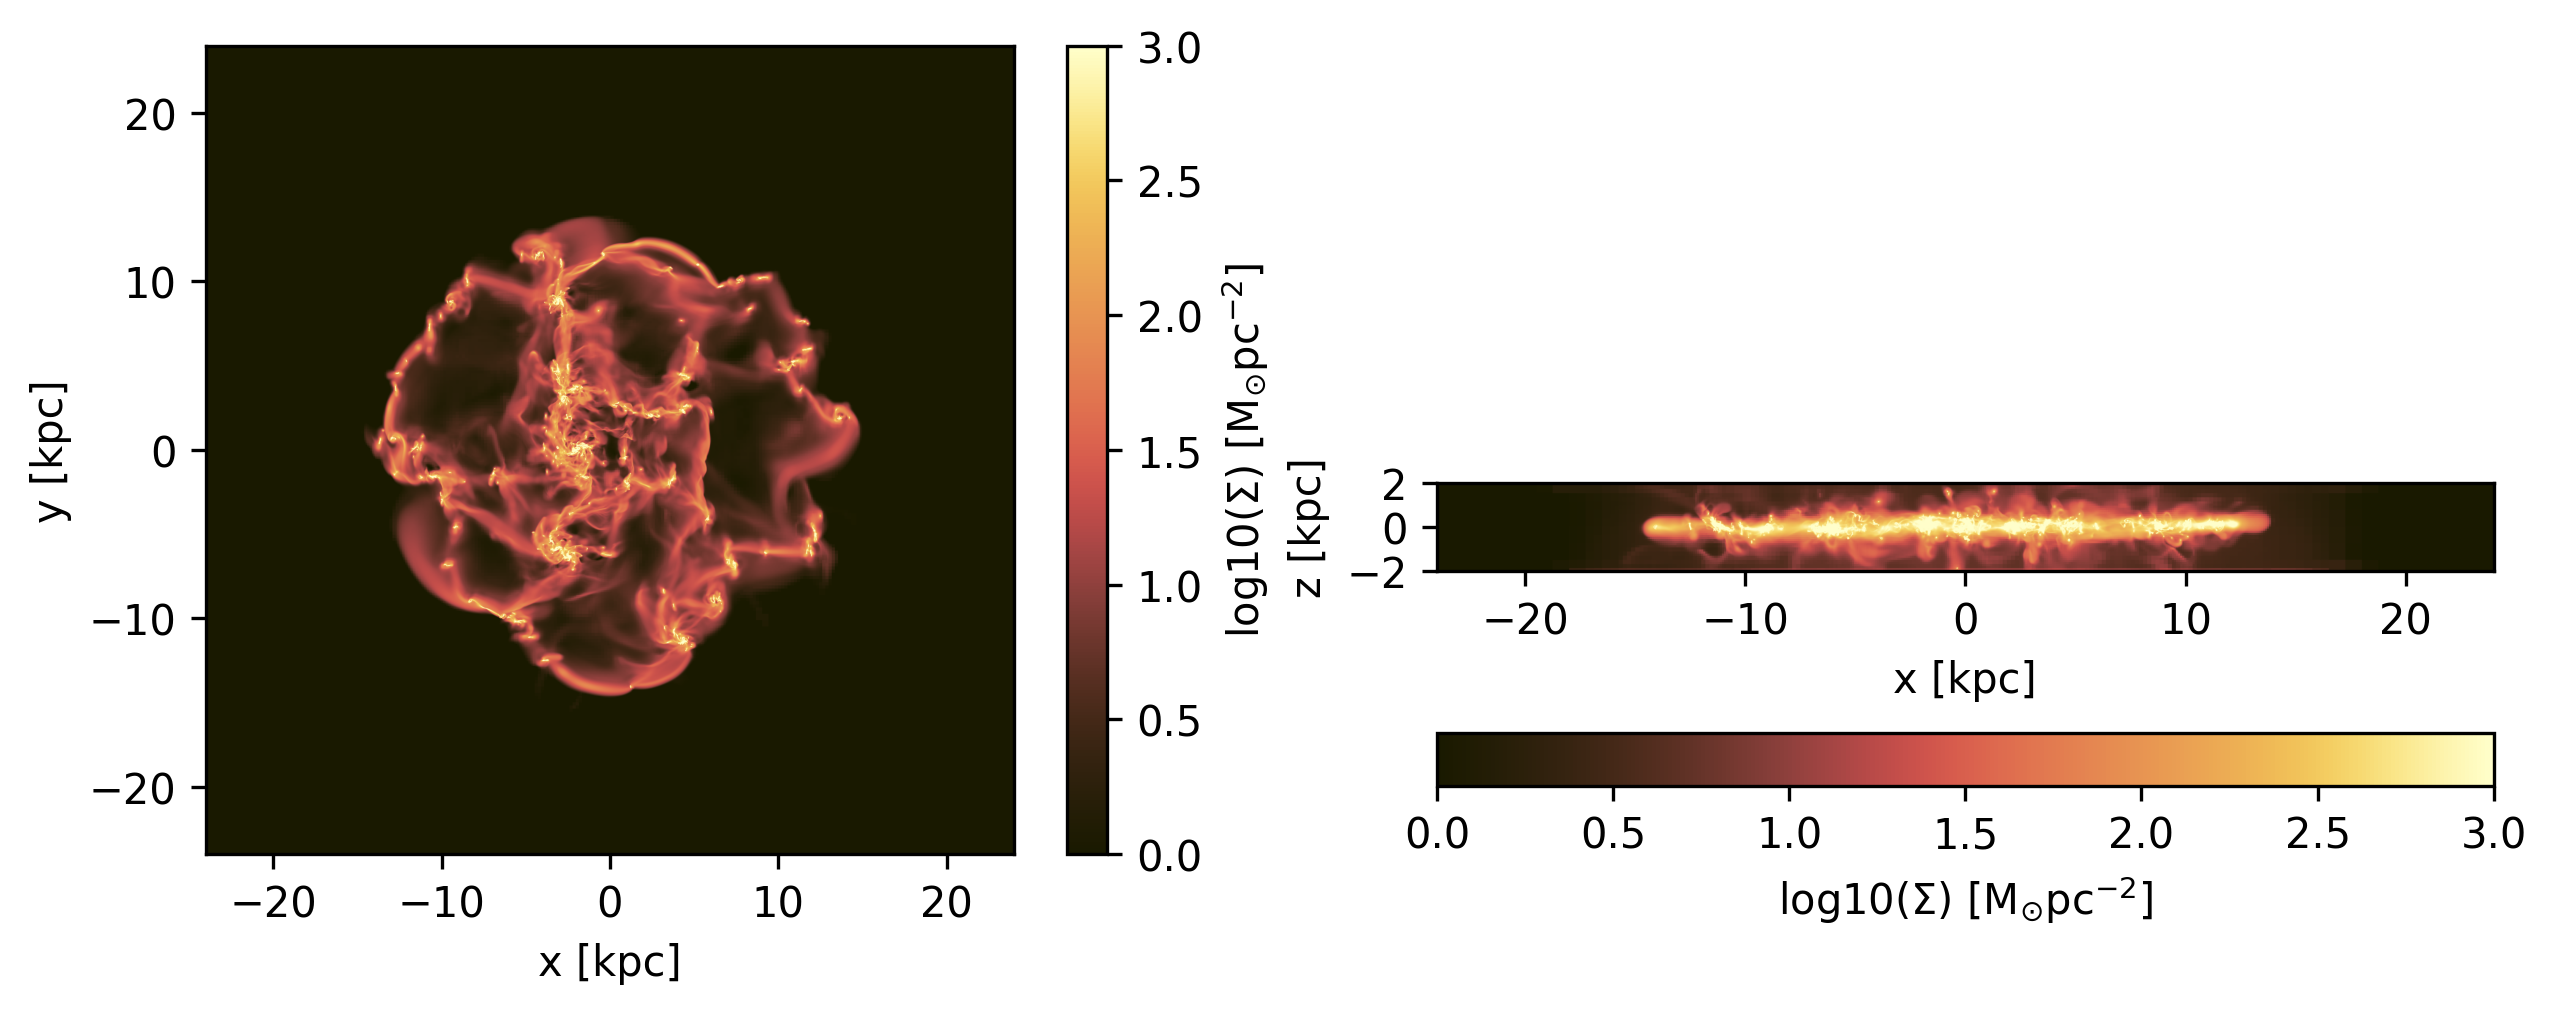

PyObject <matplotlib.colorbar.Colorbar object at 0x32bfbb760>

In [25]:
# Create professional dual-panel figure
figure(figsize=(10, 3.5))

# Left panel: Face-on view (z-direction projection)
subplot(1,2,1)
im = imshow(log10.(permutedims(proj_z.maps[:sd])),  # Transpose for correct orientation
           cmap=cmap,                               # Apply scientific colormap
           aspect=proj_z.ratio,                     # Maintain aspect ratio
           origin="lower",                          # Origin at bottom-left
           extent=getextent(proj_z, :kpc; center=true),  # kpc axes (matches the 'x [kpc]' label)
           vmin=0, vmax=3)                          # Set color scale limits
xlabel("x [kpc]")
ylabel("y [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(\Sigma) \ [M_{\odot} pc^{-2}]}")

# Right panel: Edge-on view (x-direction projection)  
subplot(1,2,2)
im = imshow(log10.(permutedims(proj_x.maps[:sd])), 
           cmap=cmap, 
           origin="lower", 
           extent=getextent(proj_x, :kpc; center=true), 
           vmin=0, vmax=3)
xlabel("x [kpc]")
ylabel("z [kpc]")
cb = colorbar(im, 
             label=L"\mathrm{log10(\Sigma) \ [M_{\odot} pc^{-2}]}", 
             orientation="horizontal", 
             pad=0.2)

In [26]:
proj_z = projection(gas, :sd, :Msol_pc2, 
                    xrange=[-5,0],
                    yrange=[-5,0],
                    zrange=[-2.,2.], center=[:bc], range_unit=:kpc,
                    verbose=false) 
proj_x = projection(gas, :sd, :Msol_pc2, 
                    xrange=[-5,0],
                    yrange=[-5,0],
                    zrange=[-2.,2.], center=[24.,24.,24.], range_unit=:kpc,
                    verbose=false, 
                    direction = :x);


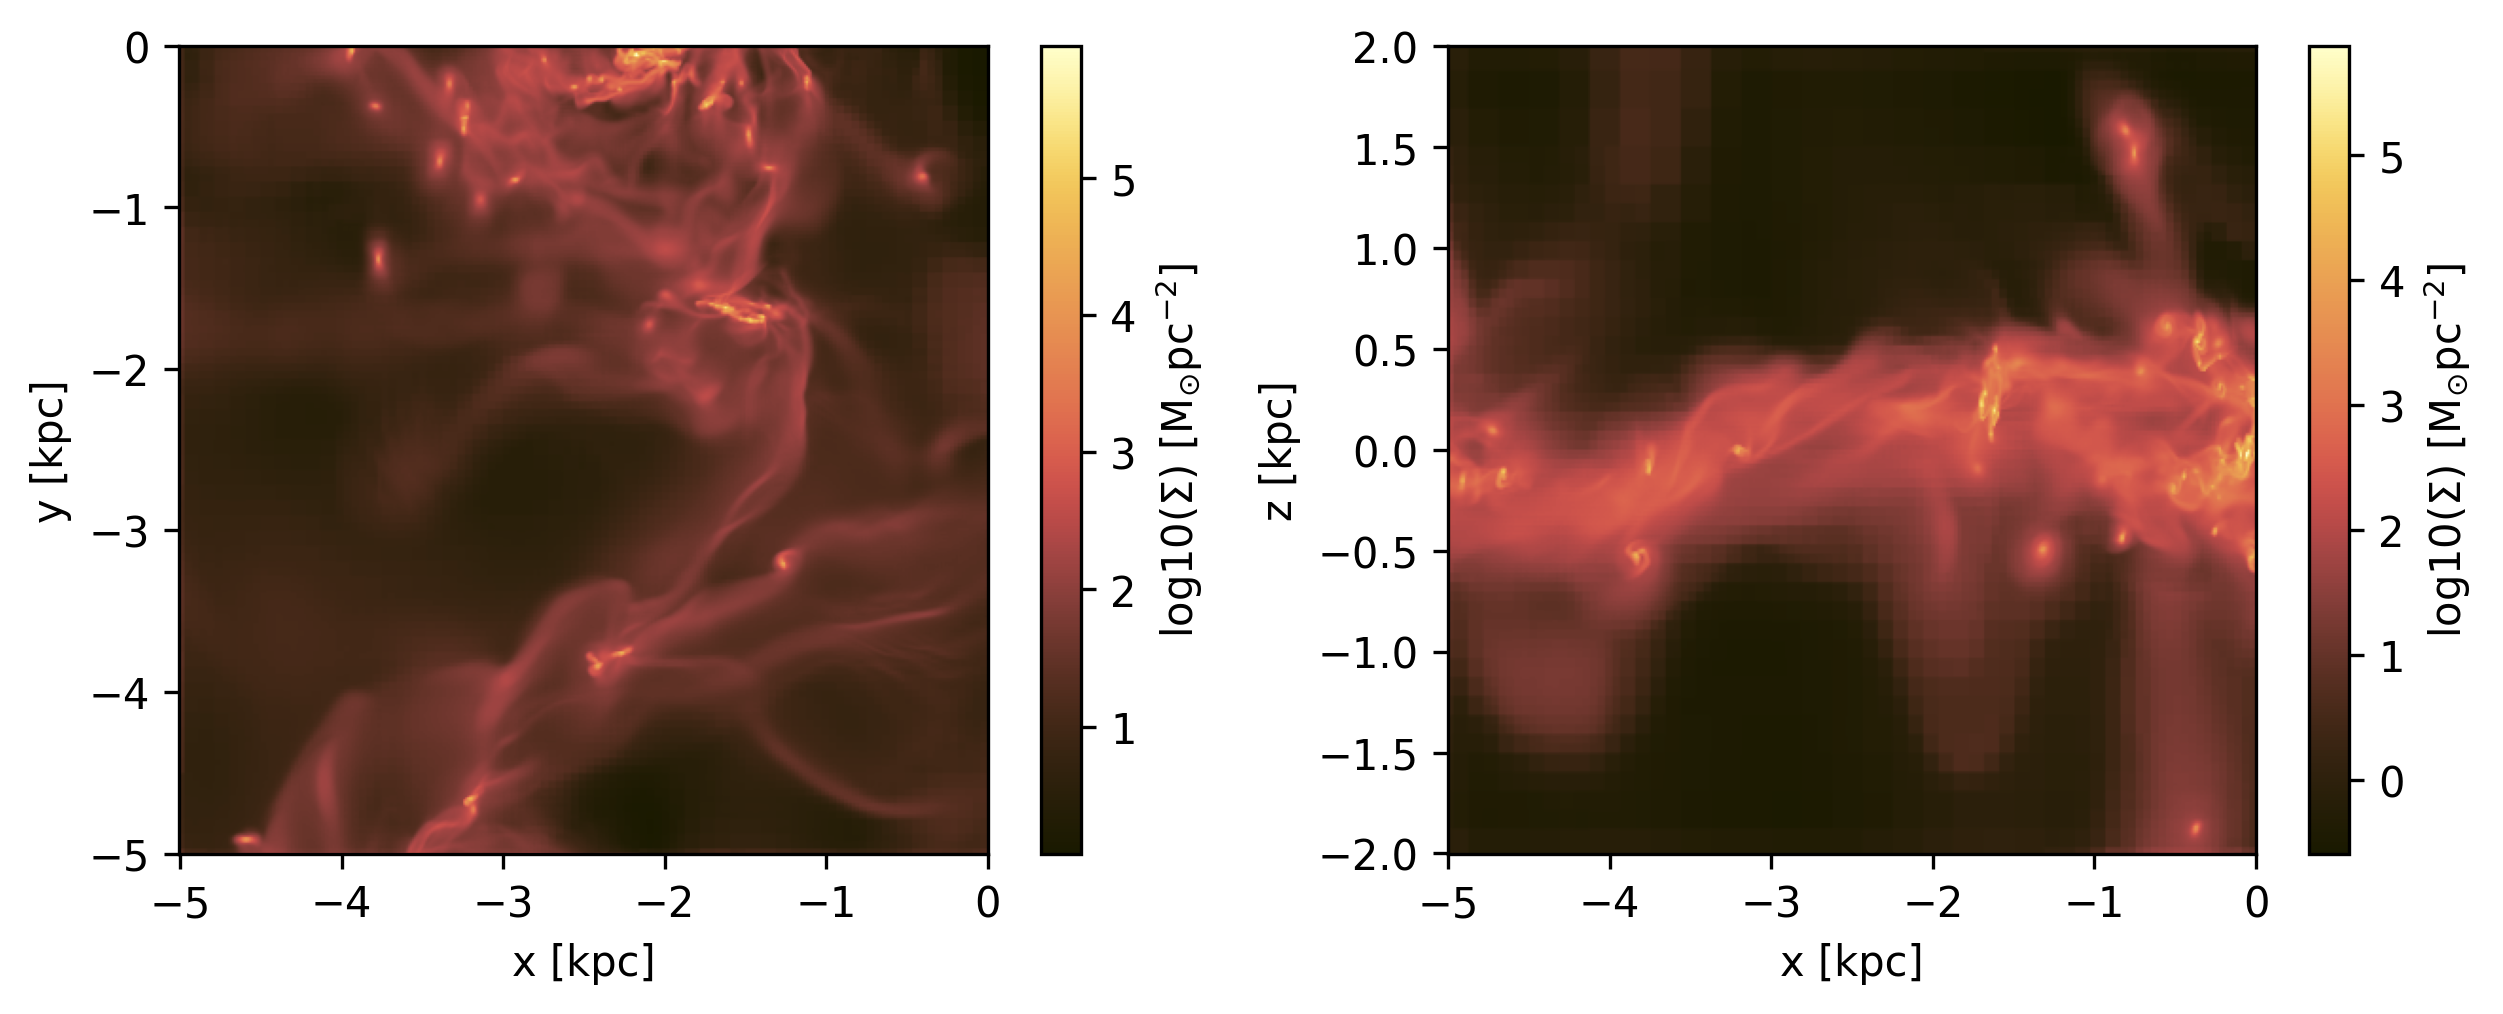

PyObject <matplotlib.colorbar.Colorbar object at 0x32c22b2b0>

In [27]:
figure(figsize=(10, 3.5))
subplot(1,2,1)
im = imshow( log10.( permutedims(proj_z.maps[:sd])), cmap=cmap, aspect=proj_z.ratio, origin="lower", extent=proj_z.cextent) #, vmin=0, vmax=3)
xlabel("x [kpc]")
ylabel("y [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(\Sigma) \ [M_{\odot} pc^{-2}]}")


subplot(1,2,2)
im = imshow( log10.( permutedims(proj_x.maps[:sd])), cmap=cmap, origin="lower", aspect=proj_x.ratio, extent=proj_x.cextent) #, vmin=0, vmax=3)
xlabel("x [kpc]")
ylabel("z [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(\Sigma) \ [M_{\odot} pc^{-2}]}") 

Project a specific spatial range and plot the axes of the map relative to the box-center (given by keyword: data_center):

## Advanced Kinematic Analysis

### Derived Velocity and Dispersion Fields

MERA.jl computes sophisticated kinematic quantities from fundamental velocity data, enabling detailed analysis of gas dynamics and turbulence properties.

#### Cartesian Coordinate Velocities

Derive kinematic properties from fundamental velocity fields:

**Available Quantities:**
- **`:v`**: Total velocity magnitude |**v**| = √(vₓ² + vᵧ² + vᵤ²)
- **`:σ`**: Total velocity dispersion (3D random motion)
- **`:σx, :σy, :σz`**: Directional velocity dispersions along coordinate axes

**Technical Implementation:**
- Mass-weighted projections by default 
- Velocity dispersion: σₓ = √(⟨vₓ²⟩ - ⟨vₓ⟩²) following standard statistical definition
- Unicode symbols supported: use `\sigma + tab` for **σ** in Julia

In [28]:
# Project comprehensive kinematic quantities
proj_z = projection(gas, [:v, :σ, :σx, :σy, :σz],  # Velocity magnitude and dispersions
                    :km_s,                          # Uniform velocity units
                    xrange=[-10.,10.], 
                    yrange=[-10.,10.], 
                    zrange=[-2.,2.], 
                    center=[24.,24.,24.], 
                    range_unit=:kpc);

[Mera]: 2026-07-03T10:11:25.140



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:v, :σ, :σx, :σy, :σz, :vx, :vx2, :vy, :vy2, :vz, :vz2, :v2, :sd) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 1708
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 9 (sd, v, v2, vx, vx2, vy, vy2, vz, vz2)
Processing mode: Variable-based parallel (4 threads)


#### Velocity Dispersion Implementation

Additional intermediate maps are automatically created for velocity dispersion calculations:

**Mathematical Formula:** σₓ = √(⟨vₓ²⟩ - ⟨vₓ⟩²)

This requires computation of both first and second moments of the velocity distribution, stored as separate map components.

In [29]:
proj_z.maps

DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering} with 13 entries:
  :sd  => [0.00356095 0.00356095 … 0.00263323 0.00263323; 0.00356095 0.00356095…
  :v   => [88.4473 88.4473 … 75.9405 75.9405; 88.4473 88.4473 … 75.9405 75.9405…
  :v2  => [1.97031 1.97031 … 1.61925 1.61925; 1.97031 1.97031 … 1.61925 1.61925…
  :vx  => [0.95769 0.95769 … -0.581239 -0.581239; 0.95769 0.95769 … -0.581239 -…
  :vx2 => [0.967715 0.967715 … 0.830687 0.830687; 0.967715 0.967715 … 0.830687 …
  :vy  => [0.318338 0.318338 … 0.0583665 0.0583665; 0.318338 0.318338 … 0.05836…
  :vy2 => [0.226201 0.226201 … 0.136131 0.136131; 0.226201 0.226201 … 0.136131 …
  :vz  => [-0.846478 -0.846478 … -0.308257 -0.308257; -0.846478 -0.846478 … -0.…
  :vz2 => [0.776394 0.776394 … 0.652433 0.652433; 0.776394 0.776394 … 0.652433 …
  :σ   => [25.4882 25.4882 … 34.5833 34.5833; 25.4882 25.4882 … 34.5833 34.5833…
  :σx  => [14.7426 14.7426 … 46.0359 46.0359; 14.7426 14.7426 … 46.0359 46.0359…
  :σy  => [23.1716 23.1716 …

In [30]:
proj_z.maps_unit

DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering} with 13 entries:
  :sd  => :standard
  :v   => :km_s
  :v2  => :standard
  :vx  => :standard
  :vx2 => :standard
  :vy  => :standard
  :vy2 => :standard
  :vz  => :standard
  :vz2 => :standard
  :σ   => :km_s
  :σx  => :km_s
  :σy  => :km_s
  :σz  => :km_s

In [31]:
usedmemory(proj_z);

Memory used: 311.886

 MB


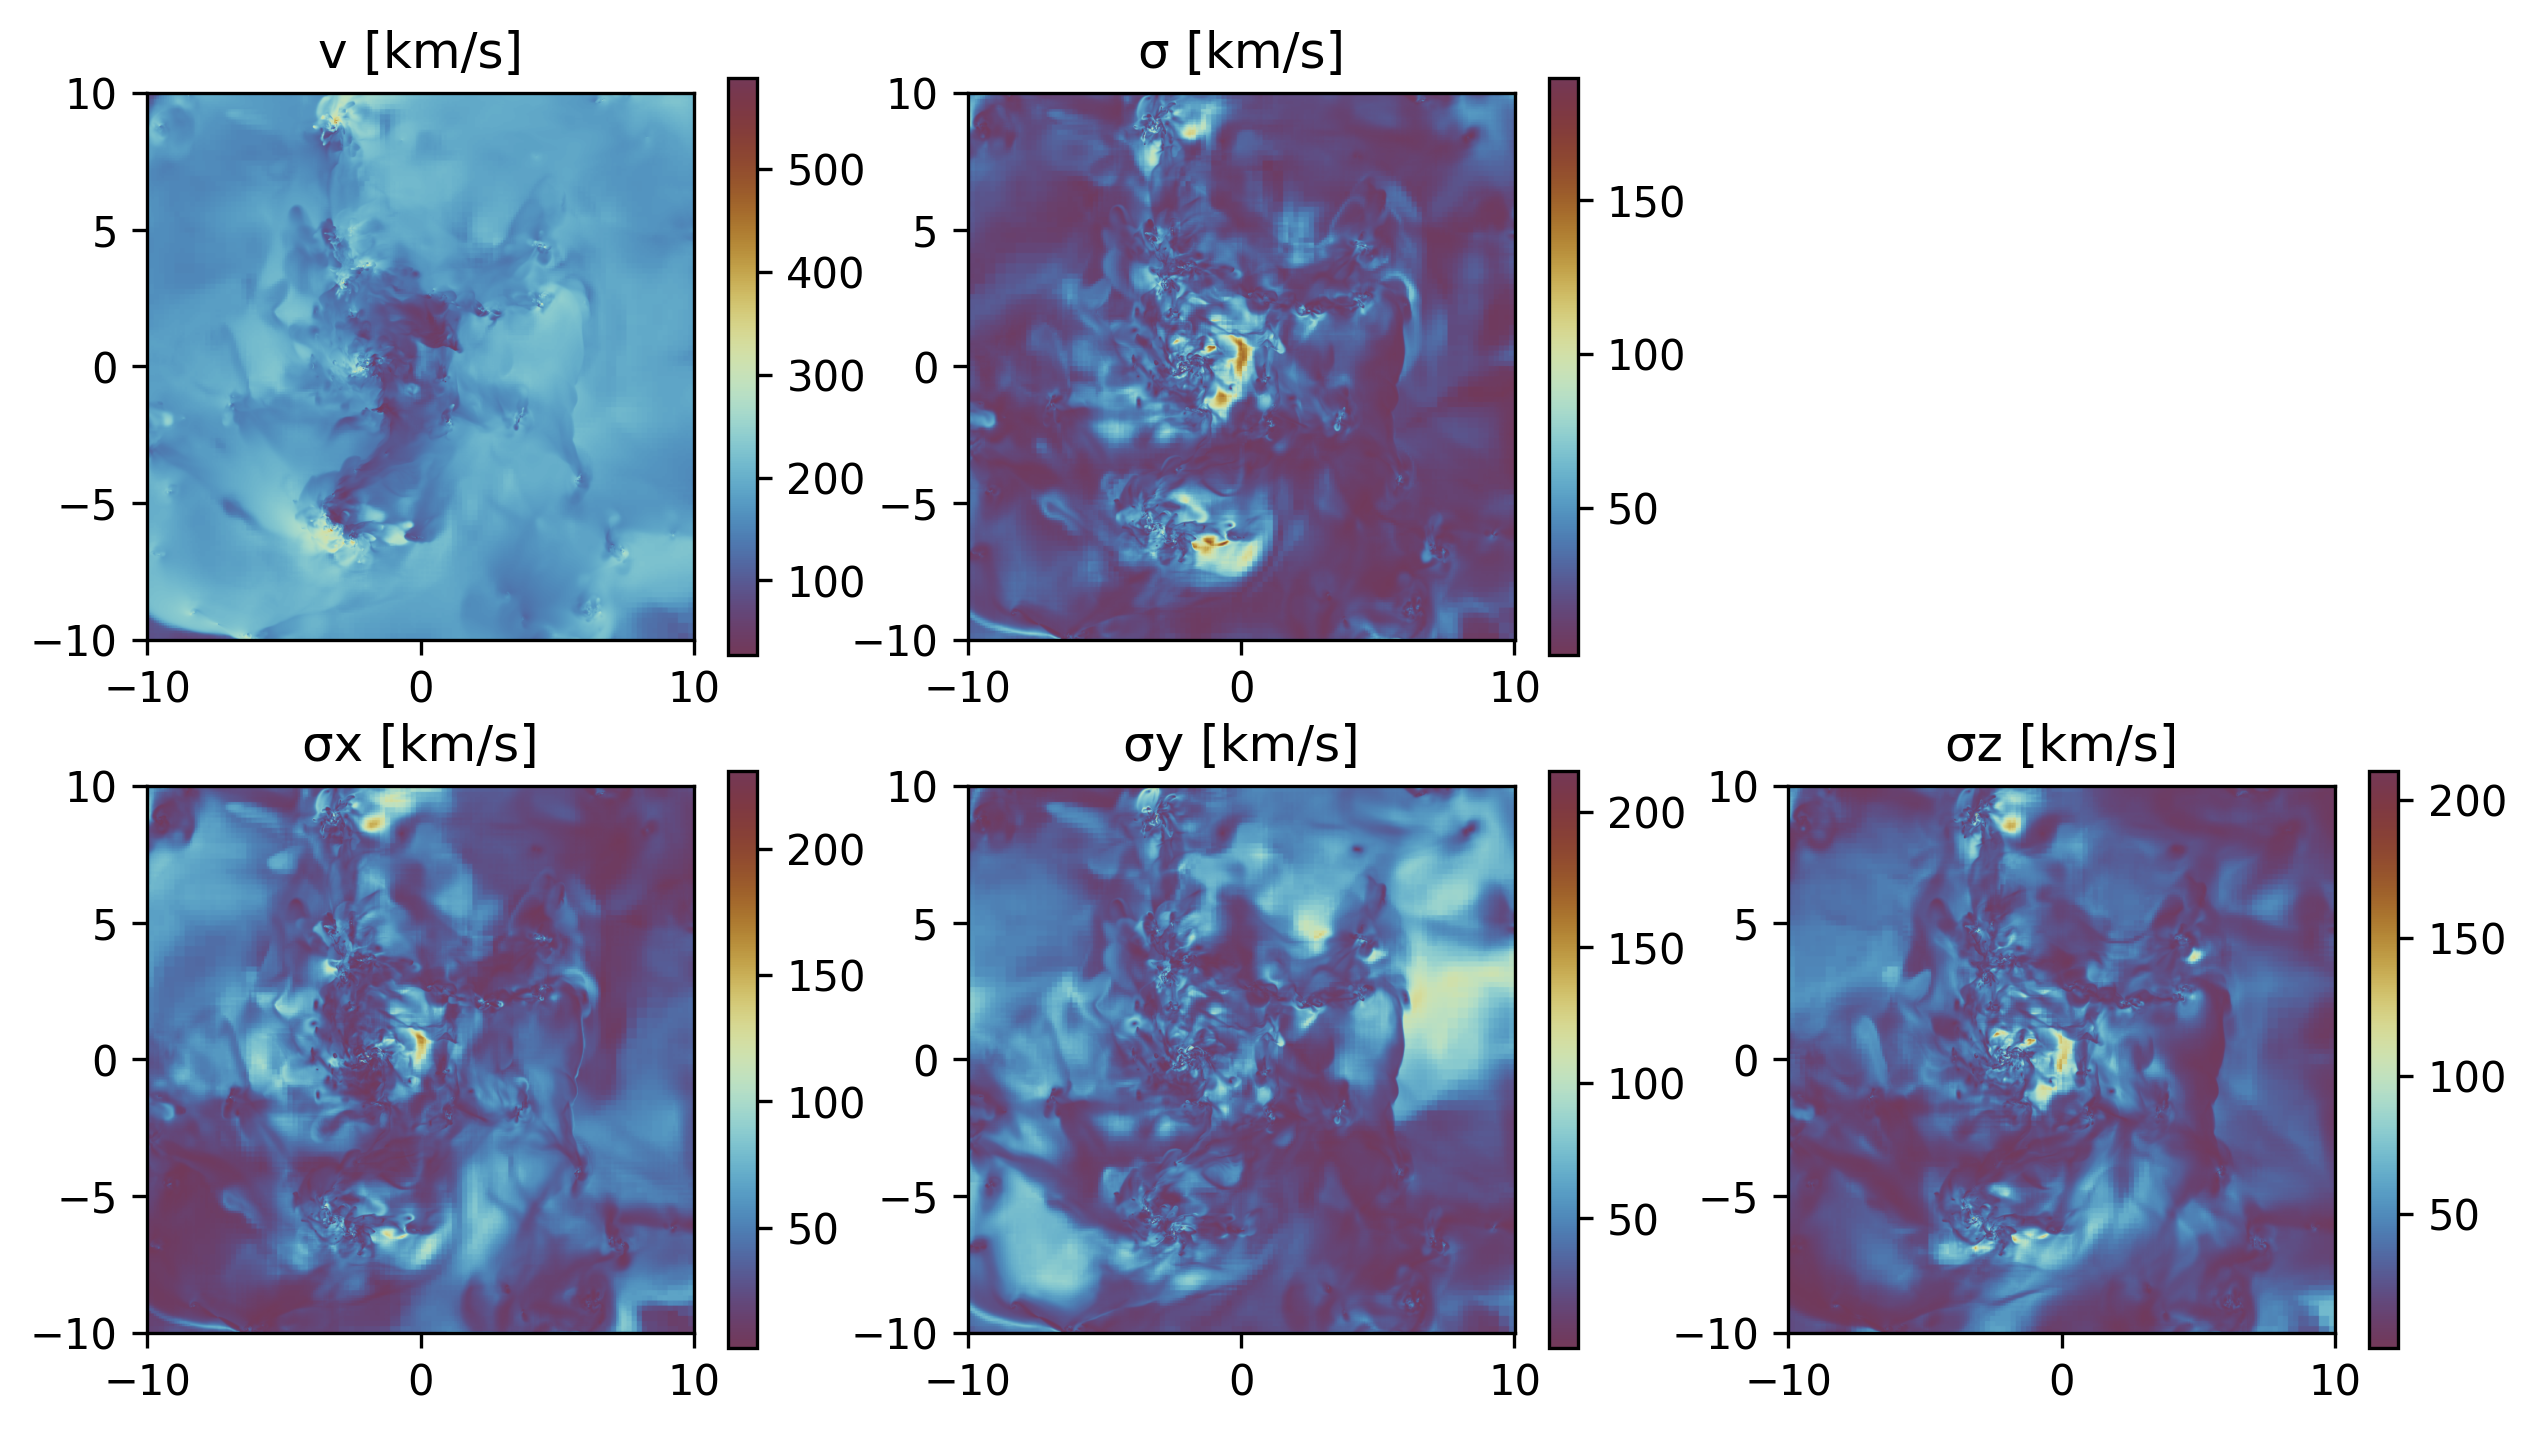

In [32]:
figure(figsize=(10, 5.5))

subplot(2, 3, 1)
title("v [km/s]")
imshow( (permutedims(proj_z.maps[:v])  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(2, 3, 2)
title("σ [km/s]")
imshow( (permutedims(proj_z.maps[:σ])  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(2, 3, 4)
title("σx [km/s]")
imshow( (permutedims(proj_z.maps[:σx])   ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(2, 3, 5)
title("σy [km/s]")
imshow( permutedims(proj_z.maps[:σy]) , cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(2, 3, 6)
title("σz [km/s]")
imshow( permutedims(proj_z.maps[:σz]) , cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar();


#### Cylindrical Coordinate System

##### Face-on Disk Analysis (z-direction)

For galactic disk studies, cylindrical coordinates provide natural physical interpretation. The coordinate transformation uses a specified center point for radius and azimuthal angle calculations.

In [33]:
# Comprehensive cylindrical coordinate analysis
proj_z = projection(gas, 
    # Cartesian quantities
    [:v, :σ, :σx, :σy,
    # Cylindrical coordinate quantities  
     :ϕ, :r_cylinder, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder],
    # Corresponding units
    units=[:km_s, :km_s, :km_s, :km_s, 
           :standard, :kpc, :km_s, :km_s, :km_s, :km_s], 
    # Spatial selection
    xrange=[-10.,10.], yrange=[-10.,10.], zrange=[-2.,2.],
    center=[:boxcenter], range_unit=:kpc,
    # Coordinate transformation center
    data_center=[24.,24.,24.], data_center_unit=:kpc);

[Mera]: 2026-07-03T10:11:32.695



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:v, :σ, :σx, :σy, :ϕ, :r_cylinder, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder, :vx, :vx2, :vy, :vy2, :v2, :vr_cylinder2, :vϕ_cylinder2, :sd) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 1708 x 1708
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 11 (sd, v, v2, vr_cylinder, vr_cylinder2, vx, vx2, vy, vy2, vϕ_cylinder, vϕ_cylinder2)
Processing mode: Variable-based parallel (4 threads)


In [34]:
proj_z.maps

DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering} with 18 entries:
  :r_cylinder   => [14.1256 14.1173 … 14.1366 14.1449; 14.1173 14.109 … 14.1283…
  :sd           => [0.00356095 0.00356095 … 0.00263323 0.00263323; 0.00356095 0…
  :v            => [88.4473 88.4473 … 75.9405 75.9405; 88.4473 88.4473 … 75.940…
  :v2           => [1.97031 1.97031 … 1.61925 1.61925; 1.97031 1.97031 … 1.6192…
  :vr_cylinder  => [-59.1678 -59.1678 … 29.4577 29.4577; -59.1678 -59.1678 … 29…
  :vr_cylinder2 => [0.975919 0.975919 … 0.602848 0.602848; 0.975919 0.975919 … …
  :vx           => [0.95769 0.95769 … -0.581239 -0.581239; 0.95769 0.95769 … -0…
  :vx2          => [0.967715 0.967715 … 0.830687 0.830687; 0.967715 0.967715 … …
  :vy           => [0.318338 0.318338 … 0.0583665 0.0583665; 0.318338 0.318338 …
  :vy2          => [0.226201 0.226201 … 0.136131 0.136131; 0.226201 0.226201 … …
  :vϕ_cylinder  => [29.646 29.646 … 24.4624 24.4624; 29.646 29.646 … 24.4624 24…
  :vϕ_cylinder2 => [0.217997

In [35]:
proj_z.maps_unit

DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering} with 18 entries:
  :r_cylinder   => :kpc
  :sd           => :standard
  :v            => :km_s
  :v2           => :standard
  :vr_cylinder  => :km_s
  :vr_cylinder2 => :standard
  :vx           => :standard
  :vx2          => :standard
  :vy           => :standard
  :vy2          => :standard
  :vϕ_cylinder  => :km_s
  :vϕ_cylinder2 => :standard
  :σ            => :km_s
  :σr_cylinder  => :km_s
  :σx           => :km_s
  :σy           => :km_s
  :σϕ_cylinder  => :km_s
  :ϕ            => :radian

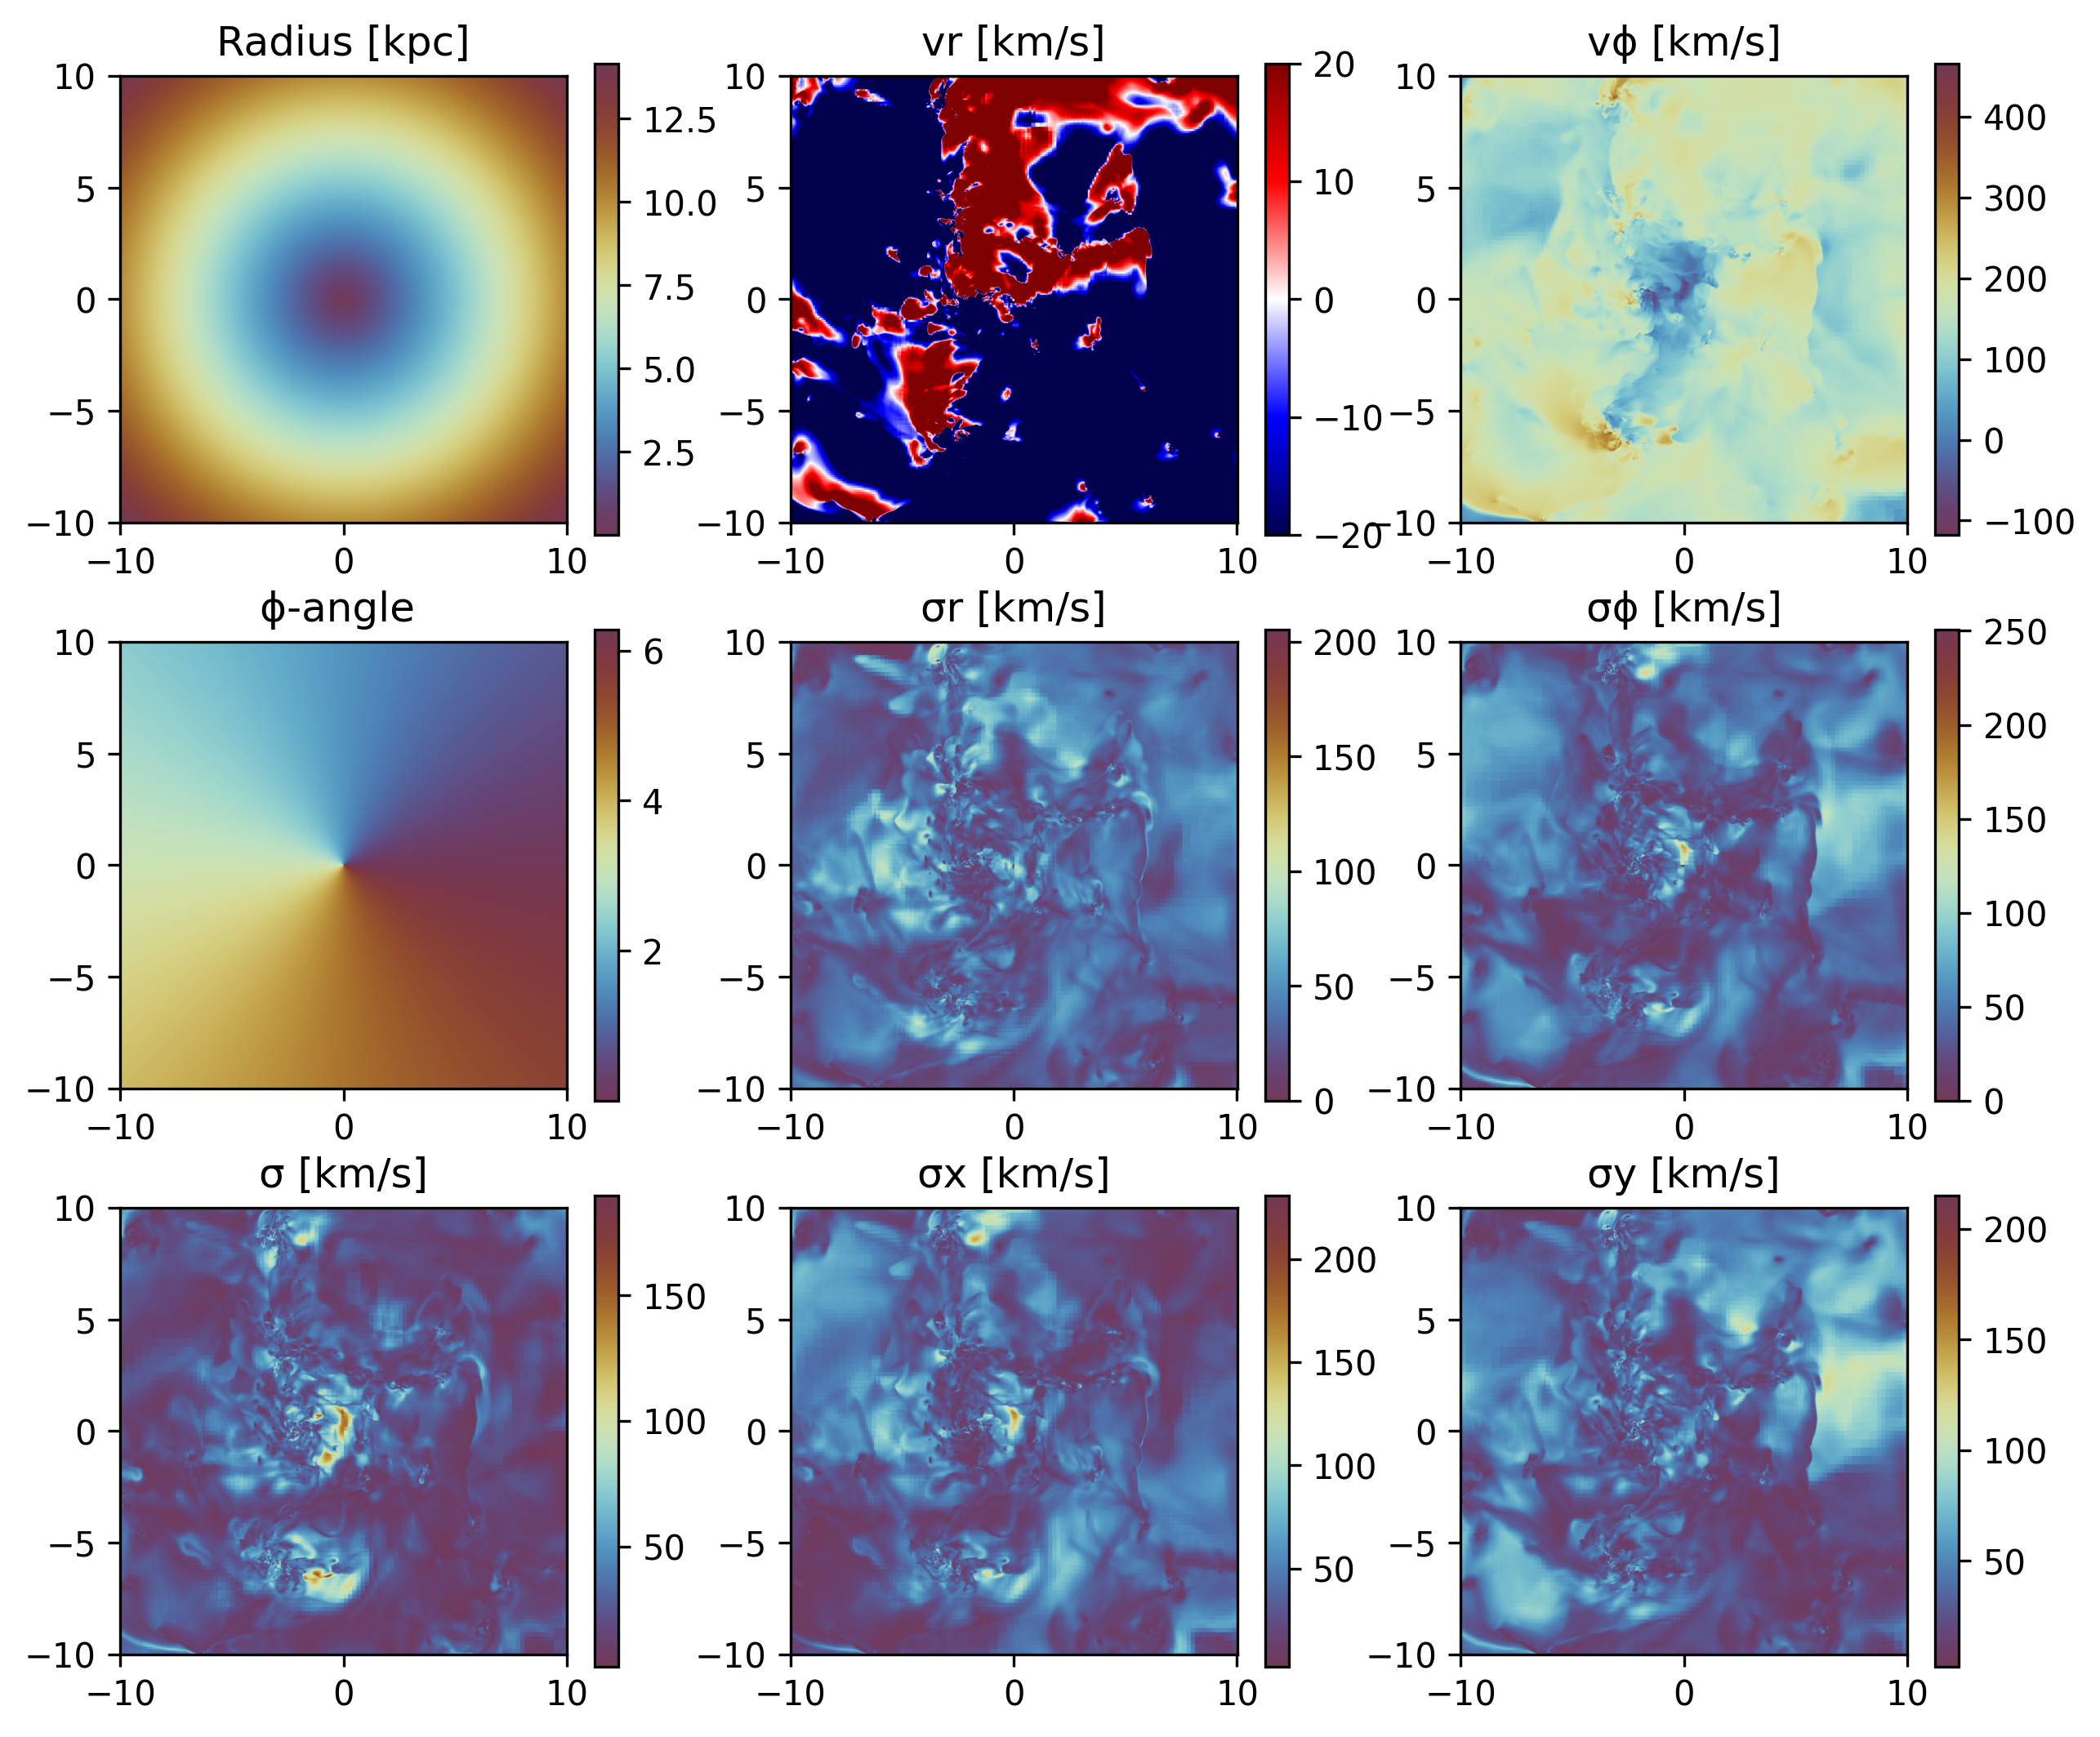

In [36]:
figure(figsize=(10, 8.5))

subplot(3, 3, 1)
title("Radius [kpc]")
imshow( permutedims(proj_z.maps[:r_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 2)
title("vr [km/s]")
imshow( permutedims(proj_z.maps[:vr_cylinder] ), cmap="seismic", origin="lower", extent=proj_z.cextent, vmin=-20.,vmax=20.)
colorbar()


subplot(3, 3, 3)
title("vϕ [km/s]")
imshow( permutedims(proj_z.maps[:vϕ_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 4)
title("ϕ-angle ")
imshow( permutedims(proj_z.maps[:ϕ]) , cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 5)
title("σr [km/s]")
imshow( permutedims(proj_z.maps[:σr_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 6)
title("σϕ [km/s]")
imshow( permutedims(proj_z.maps[:σϕ_cylinder] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 7)
title("σ [km/s]")
imshow( permutedims(proj_z.maps[:σ]) , cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 8)
title("σx [km/s]")
imshow( permutedims(proj_z.maps[:σx] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 9)
title("σy [km/s]")
imshow( permutedims(proj_z.maps[:σy] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar();

### Performance Tips for Kinematic Analysis

#### Memory Optimization
Kinematic projections can be memory-intensive due to multiple intermediate calculations:

```julia
# Memory-efficient approach: Process quantities separately
proj_velocity = projection(gas, [:vx, :vy, :vz], :km_s, lmax=6)
proj_dispersion = projection(gas, [:σx, :σy, :σz], :km_s, lmax=6)

# Check memory usage
usedmemory(proj_velocity)
usedmemory(proj_dispersion)
```

#### Computational Efficiency
```julia
# For exploratory analysis: use coarser resolution
proj_explore = projection(gas, [:v, :σ], :km_s, lmax=6)

# For publication: increase resolution selectively
proj_final = projection(gas, [:v, :σ], :km_s, 
                       xrange=[-5,5], yrange=[-5,5],  # Focus on core
                       lmax=10)                       # High resolution
```

#### Threading Considerations
```julia
# Monitor threading performance for optimization
proj = projection(gas, [:v, :σ, :σx, :σy, :σz], :km_s,
                 verbose_threads=true)  # Shows parallel efficiency
```

## Grid Resolution Control

### Adaptive Resolution Selection

Control projection grid resolution to balance computational efficiency with spatial detail. MERA.jl offers multiple resolution specification methods to suit different analysis requirements.

#### Refinement Level Control (`lmax`)

The `lmax` parameter controls grid resolution through AMR level specification:

**Key Features:**
- **Default Behavior**: Uses maximum loaded refinement level for highest available resolution
- **Coarser Grids**: Lower `lmax` values reduce computational cost and memory usage
- **Independence**: Can exceed simulation's maximum level for interpolated higher resolution
- **Grid Scaling**: Resolution = 2^lmax grid cells along each dimension

In [37]:
# Project on coarser grid (level 6) for faster computation
proj_z = projection(gas, 
    [:v, :σ, :σx, :σy, :σz, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder], 
    :km_s,
    xrange=[-10.,10.], yrange=[-10.,10.], zrange=[-2.,2.],
    center=[:boxcenter], range_unit=:kpc,
    lmax=6);  # 2^6 = 64 grid cells per dimension

[Mera]: 2026-07-03T10:11:45.790



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:v, :σ, :σx, :σy, :σz, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder, :vx, :vx2, :vy, :vy2, :vz, :vz2, :v2, :vr_cylinder2, :vϕ_cylinder2, :sd) 
Weighting      = :mass

Effective resolution: 64^2
Map size: 28 x 28
Pixel size: 750.0 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 13 (sd, v, v2, vr_cylinder, vr_cylinder2, vx, vx2, vy, vy2, vz, vz2, vϕ_cylinder, vϕ_cylinder2)
Processing mode: Variable-based parallel (4 threads)


In [38]:
# this corresponds to an effective resolution of:
proj_z.effres

64

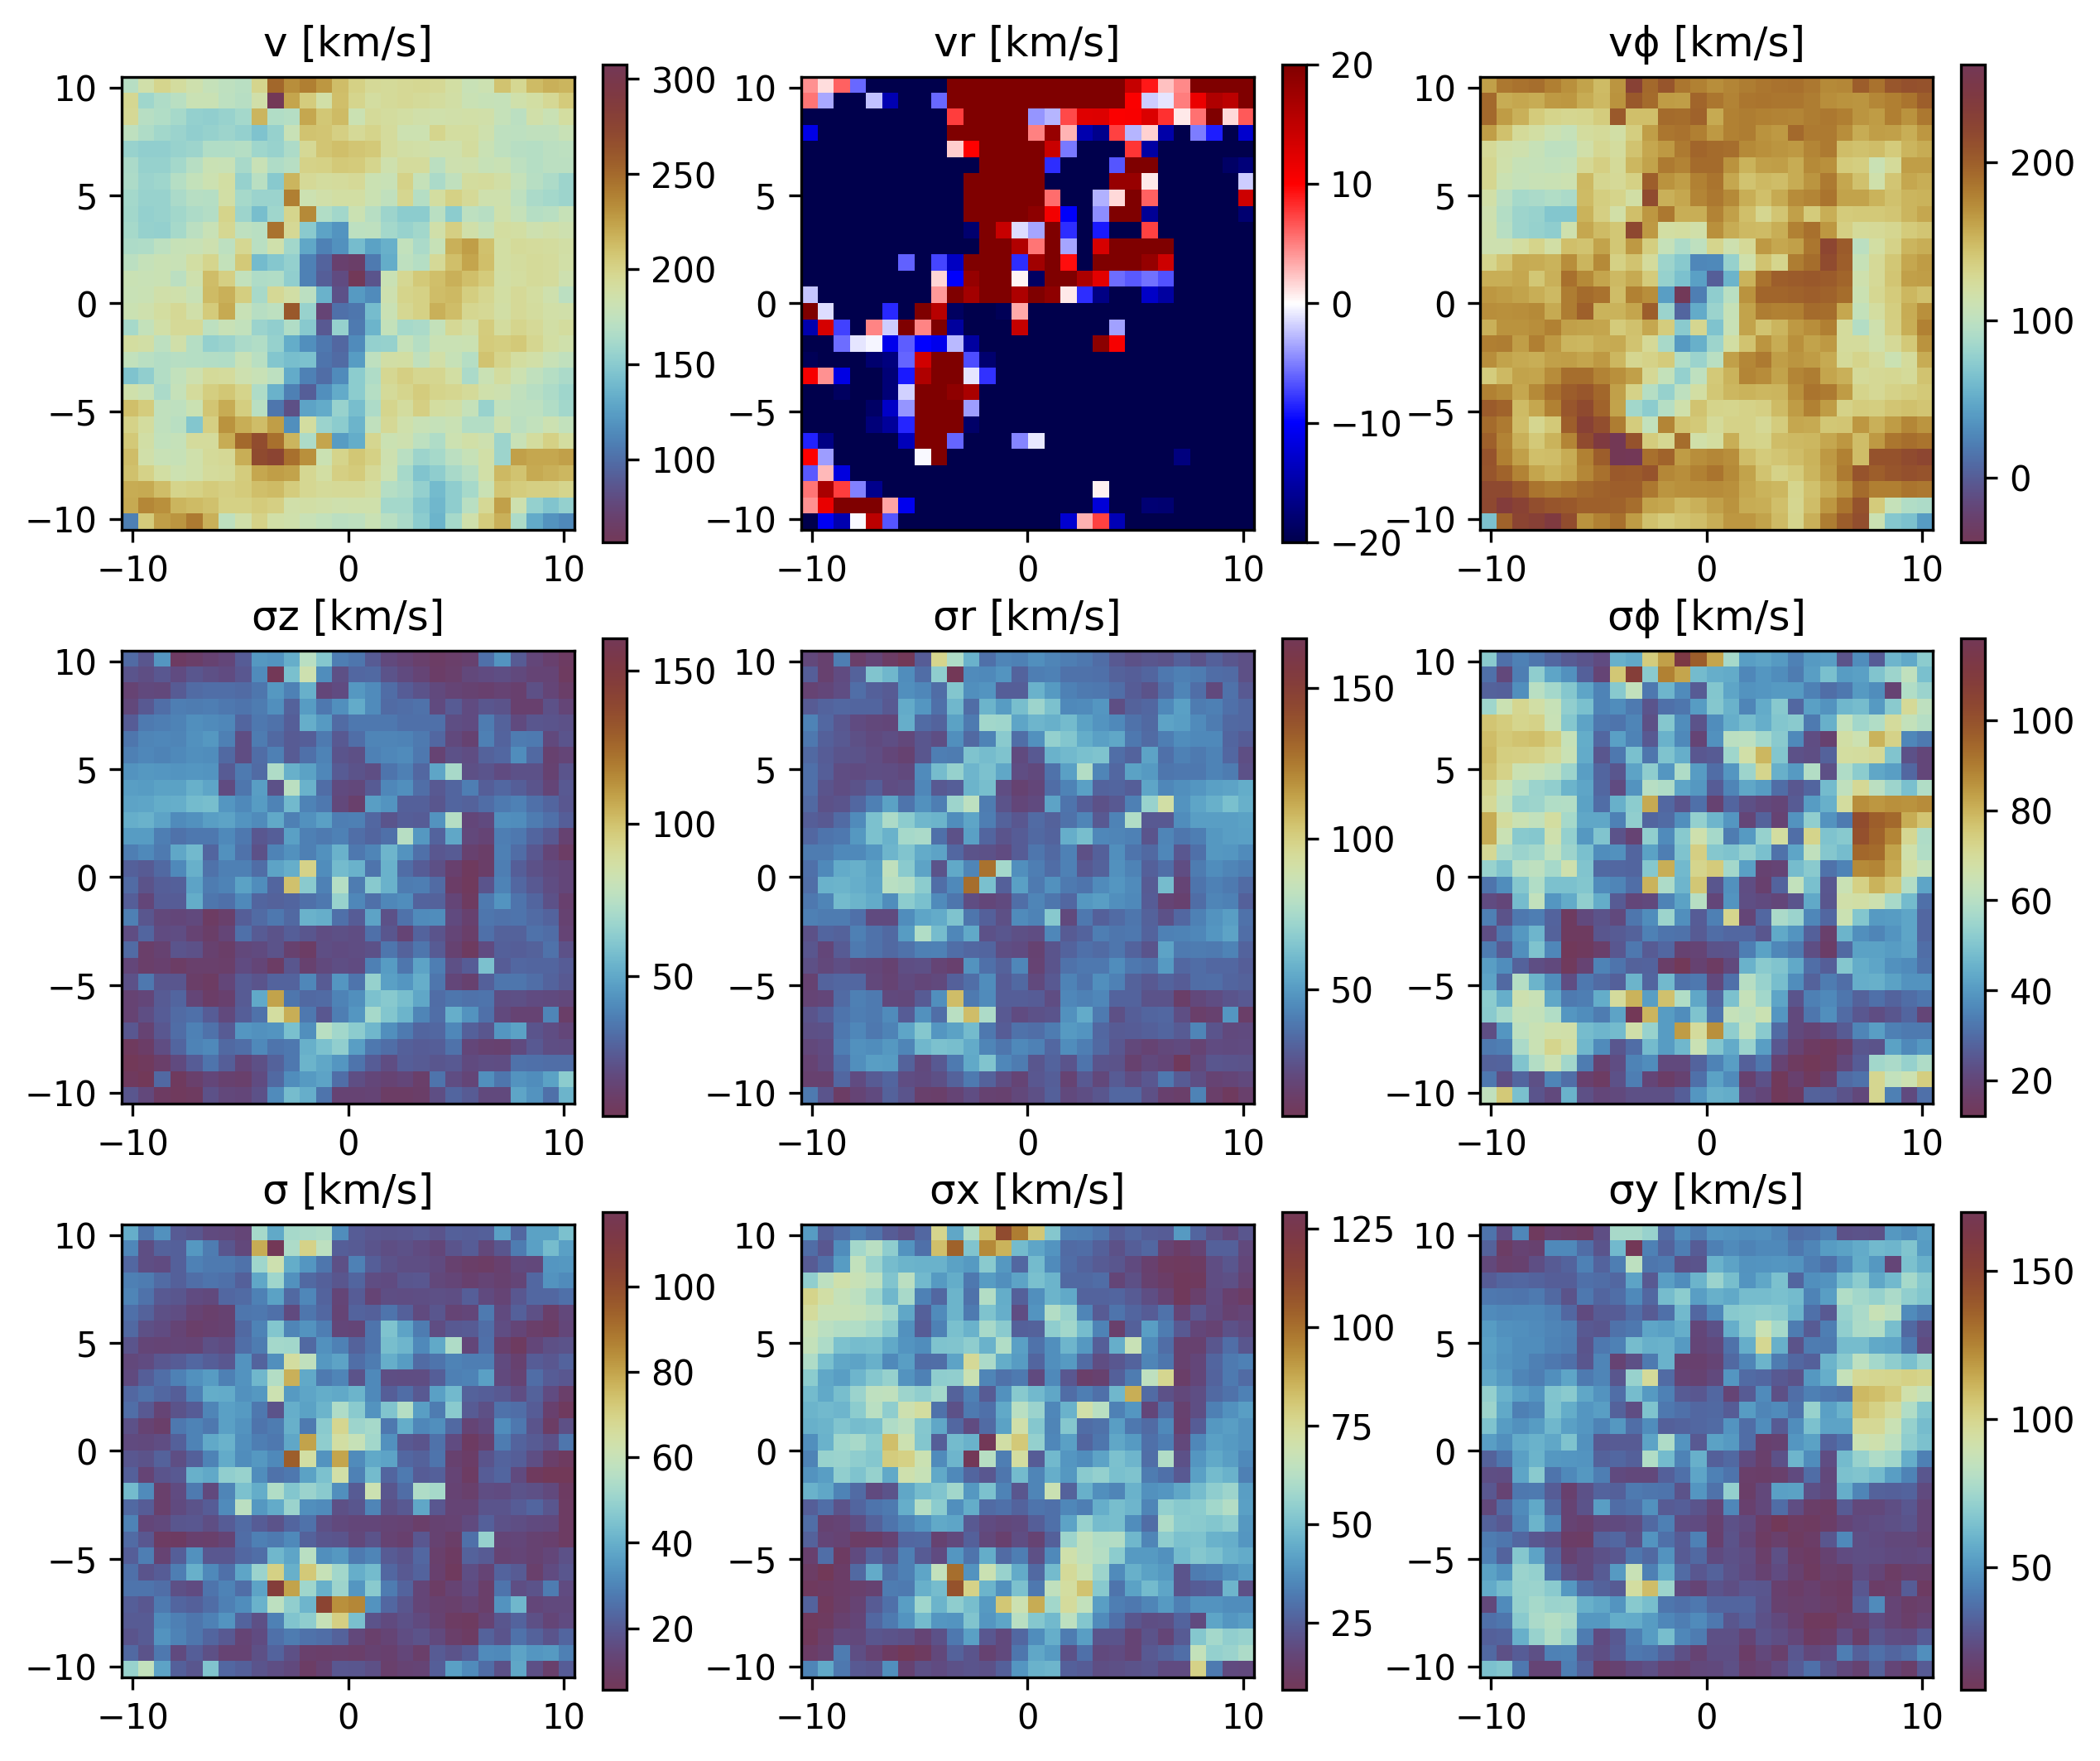

In [39]:
figure(figsize=(10, 8.5))

subplot(3, 3, 1)
title("v [km/s]")
imshow( permutedims(proj_z.maps[:v]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 2)
title("vr [km/s]")
imshow( permutedims(proj_z.maps[:vr_cylinder] ), cmap="seismic", origin="lower", extent=proj_z.cextent, vmin=-20.,vmax=20.)
colorbar()


subplot(3, 3, 3)
title("vϕ [km/s]")
imshow( permutedims(proj_z.maps[:vϕ_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 4)
title("σz [km/s]")
imshow( permutedims(proj_z.maps[:σz] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 5)
title("σr [km/s]")
imshow( permutedims(proj_z.maps[:σr_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 6)
title("σϕ [km/s]")
imshow( permutedims(proj_z.maps[:σϕ_cylinder] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 7)
title("σ [km/s]")
imshow( permutedims(proj_z.maps[:σ]) , cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 8)
title("σx [km/s]")
imshow( permutedims(proj_z.maps[:σx]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 9)
title("σy [km/s]")
imshow( permutedims(proj_z.maps[:σy] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar();

#### Direct Resolution Specification (`res`)

Specify absolute grid resolution independent of AMR levels:

In [40]:
# Direct resolution specification: 100x100 grid
proj_z = projection(gas, 
    [:v, :σ, :σx, :σy, :σz, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder], 
    :km_s,
    xrange=[-10.,10.], yrange=[-10.,10.], zrange=[-2.,2.],
    center=[:boxcenter], range_unit=:kpc,
    pxsize=[0.5, :kpc]);  # 0.5 kpc pixels (~96x96 over the 48 kpc box)

[Mera]: 2026-07-03T10:11:54.156



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:v, :σ, :σx, :σy, :σz, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder, :vx, :vx2, :vy, :vy2, :vz, :vz2, :v2, :vr_cylinder2, :vϕ_cylinder2, :sd) 
Weighting      = :mass

Effective resolution: 97^2
Map size: 41 x 41
Pixel size: 494.845 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 13 (sd, v, v2, vr_cylinder, vr_cylinder2, vx, vx2, vy, vy2, vz, vz2, vϕ_cylinder, vϕ_cylinder2)
Processing mode: Variable-based parallel (4 threads)


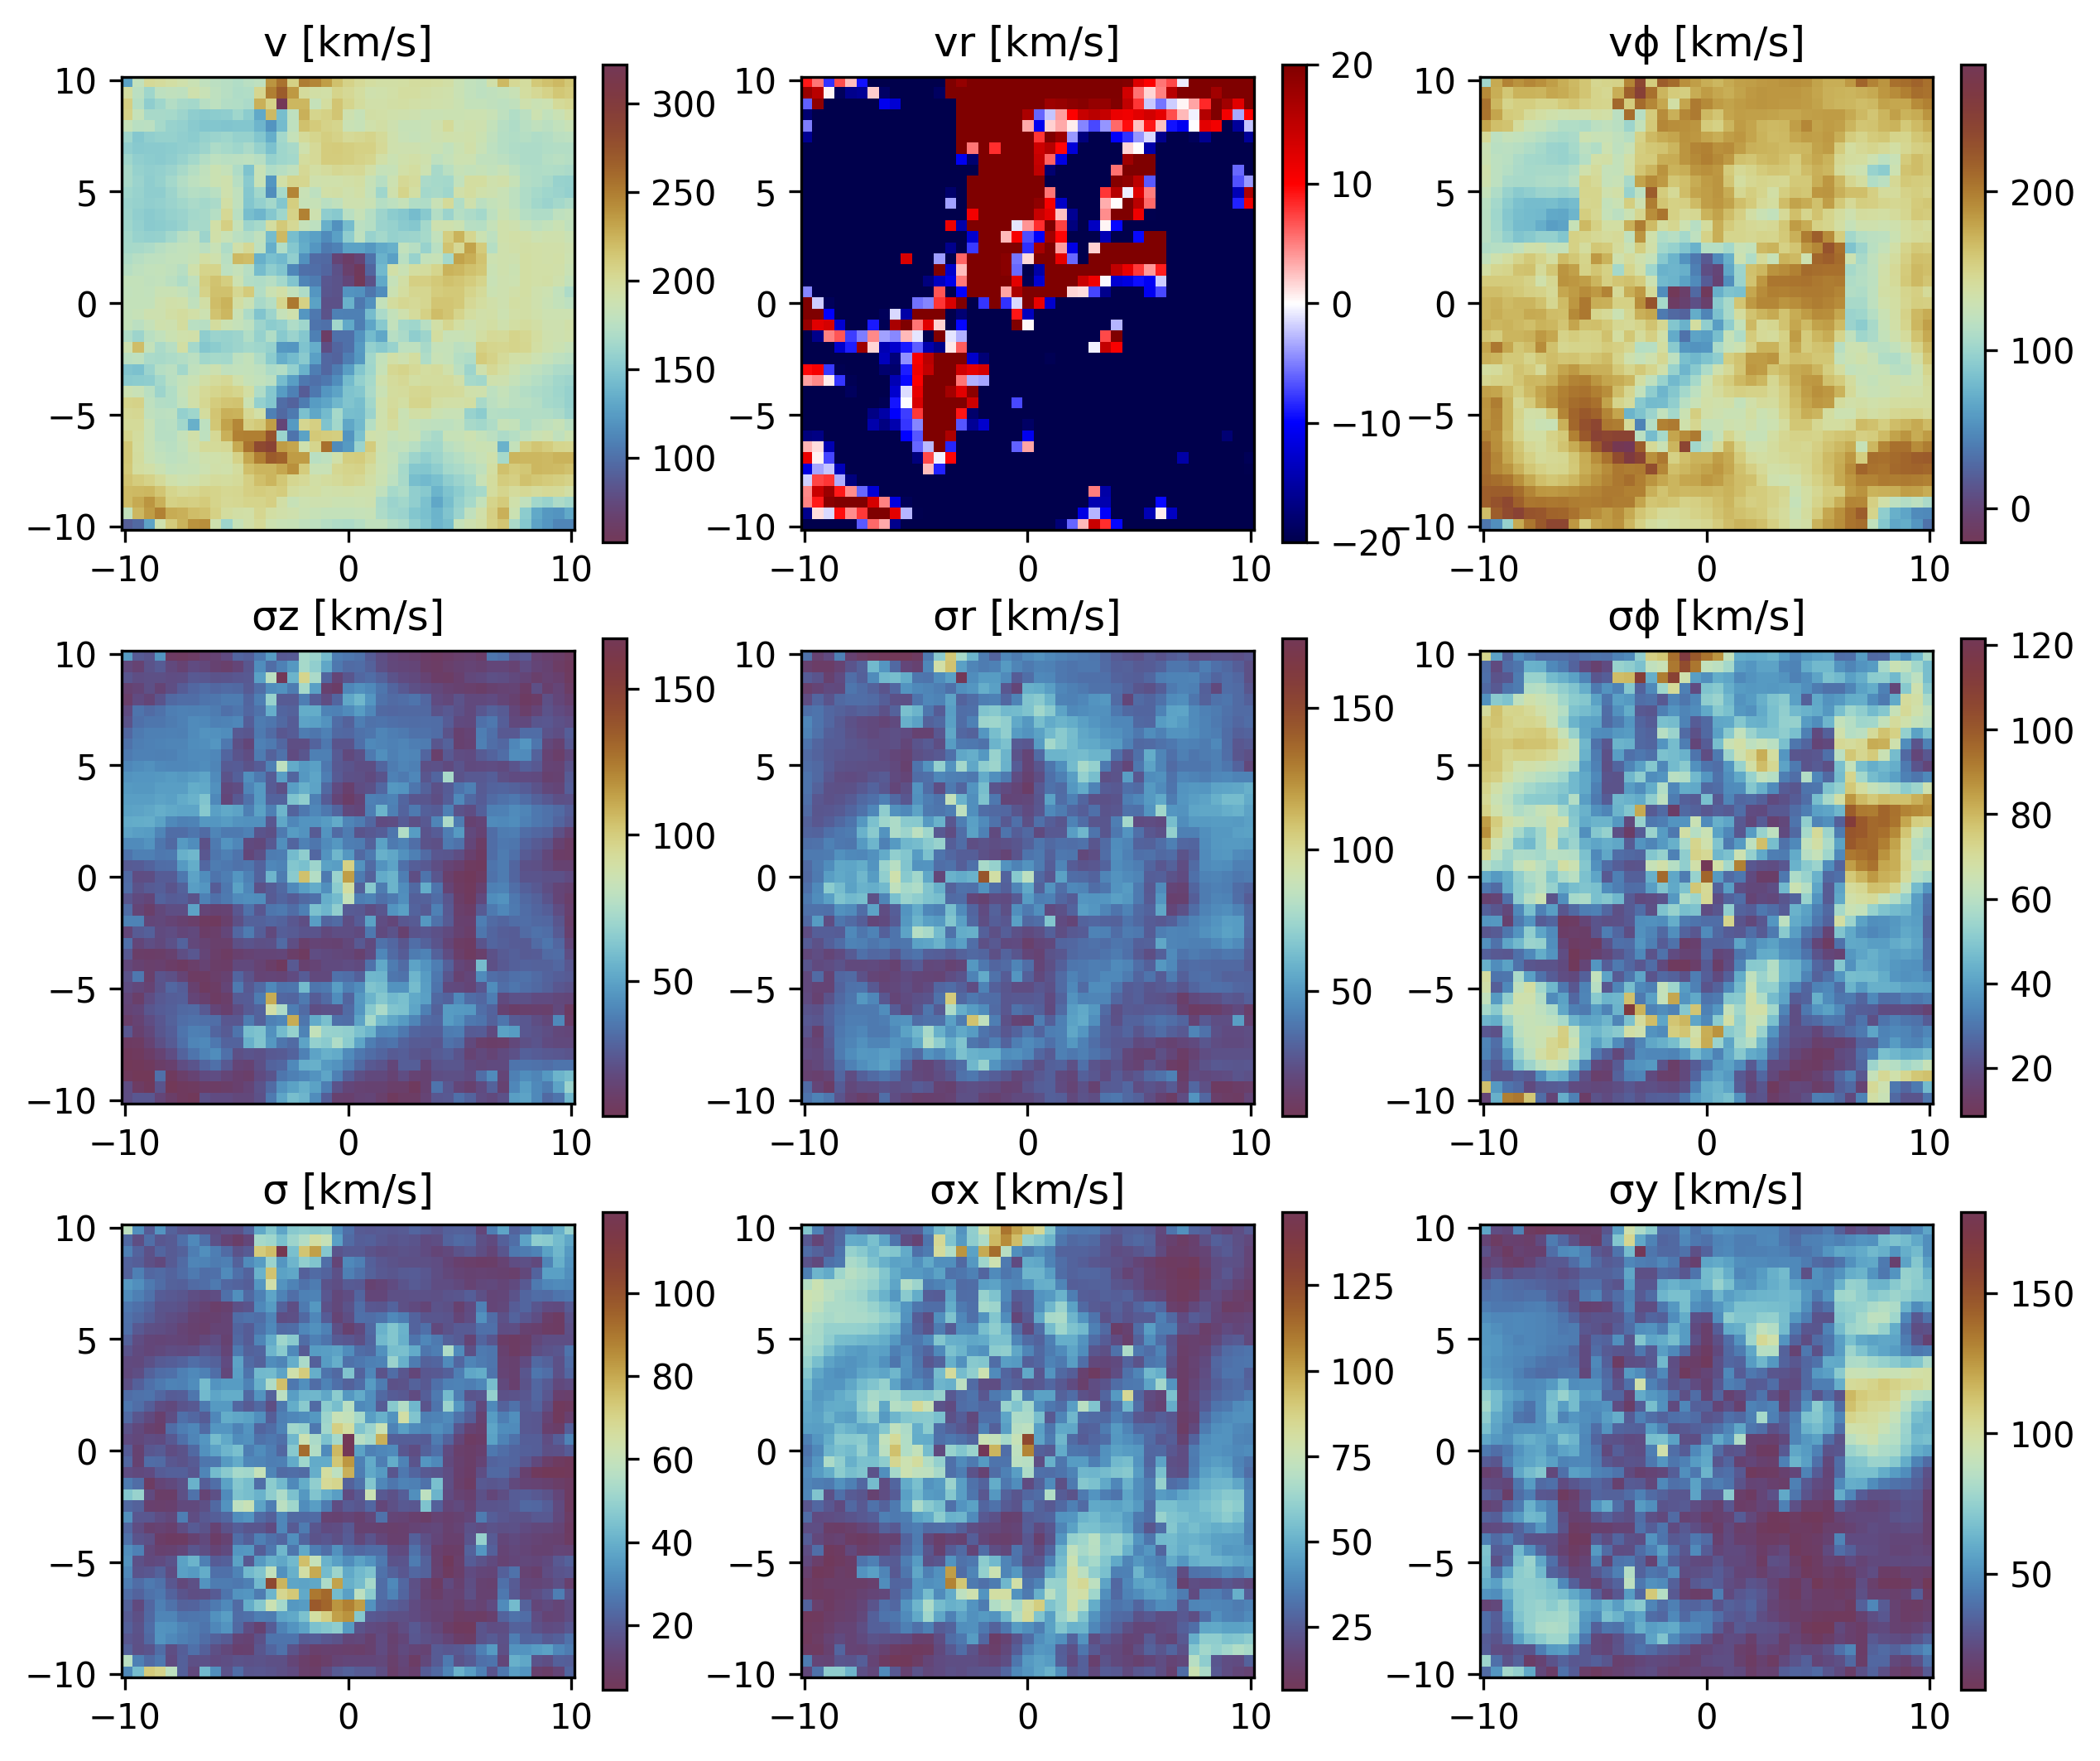

In [41]:
figure(figsize=(10, 8.5))

subplot(3, 3, 1)
title("v [km/s]")
imshow( permutedims(proj_z.maps[:v]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 2)
title("vr [km/s]")
imshow( permutedims(proj_z.maps[:vr_cylinder] ), cmap="seismic", origin="lower", extent=proj_z.cextent, vmin=-20.,vmax=20.)
colorbar()


subplot(3, 3, 3)
title("vϕ [km/s]")
imshow( permutedims(proj_z.maps[:vϕ_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 4)
title("σz [km/s]")
imshow( permutedims(proj_z.maps[:σz] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 5)
title("σr [km/s]")
imshow( permutedims(proj_z.maps[:σr_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 6)
title("σϕ [km/s]")
imshow( permutedims(proj_z.maps[:σϕ_cylinder] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 7)
title("σ [km/s]")
imshow( permutedims(proj_z.maps[:σ]) , cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 8)
title("σx [km/s]")
imshow( permutedims(proj_z.maps[:σx]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 9)
title("σy [km/s]")
imshow( permutedims(proj_z.maps[:σy] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar();

#### Physical Pixel Size Control (`pxsize`)

Specify resolution through physical pixel dimensions for direct scale control:

In [42]:
# Physical pixel size specification
proj_z = projection(gas, 
    [:v, :σ, :σx, :σy, :σz, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder], 
    :km_s,
    xrange=[-10.,10.], yrange=[-10.,10.], zrange=[-2.,2.],
    center=[:boxcenter], range_unit=:kpc,
    pxsize=[1000., :pc],      # 1000 pc per pixel (1 kpc/pixel)
    verbose_threads=true);     # Show threading information

[Mera]: 2026-07-03T10:12:00.896

center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
ymin::ymax: 0.2916667 :: 0.7083333  	==> 14.0 [kpc] :: 34.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:v, :σ, :σx, :σy, :σz, :vr_cylinder, :vϕ_cylinder, :σr_cylinder, :σϕ_cylinder, :vx, :vx2, :vy, :vy2, :vz, :vz2, :v2, :vr_cylinder2, :vϕ_cylinder2, :sd) 
Weighting      = :mass

Effective resolution: 49^2
Map size: 21 x 21
Pixel size: 979.592 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 13 (sd, v, v2, vr_cylinder, vr_cylinder2, vx, vx2, vy, vy2, vz, vz2, vϕ_cylinder, vϕ_cylinder2)
Processing mode: Variable-based parallel (4 threads)
🚀 Variable-based parallel processing with 4 threads
   ├─ Variables: 13 across AMR levels 6 to 12
   ├─ Total cells: 18590638
   ├─ Cells per variable: 1430049
   └─ Expected efficiency: 85-95% (no combining overhead)
🚀 Using variable-based parallel processing
   Variables: 13 (sd, v, v2, vr_cylinder, vr_cylinder2, vx, vx2, vy, vy2, vz, vz2, vϕ_cylinder, vϕ_cylinder2)
   Processing levels 6 to 12
   🧵 Thread allocation: sd→T1, v→T2, v2→T3, vr_cylinder→T4


✅ Variable-based parallel processing completed in 2.26s
   ⚡ No combining phase needed - direct variable assignment eliminates overhead!
   📊 Performance Metrics:
      ├─ Total operations: 241678294 (18590638 cells × 13 vars)
      ├─ Processing rate: 106949924 cells/second
      ├─ Parallel efficiency: 100.0% (target: 85-95%)
      ├─ Threads utilized: 4 / 4 available
      └─ Memory benefit: Direct allocation (no intermediate combining buffers)


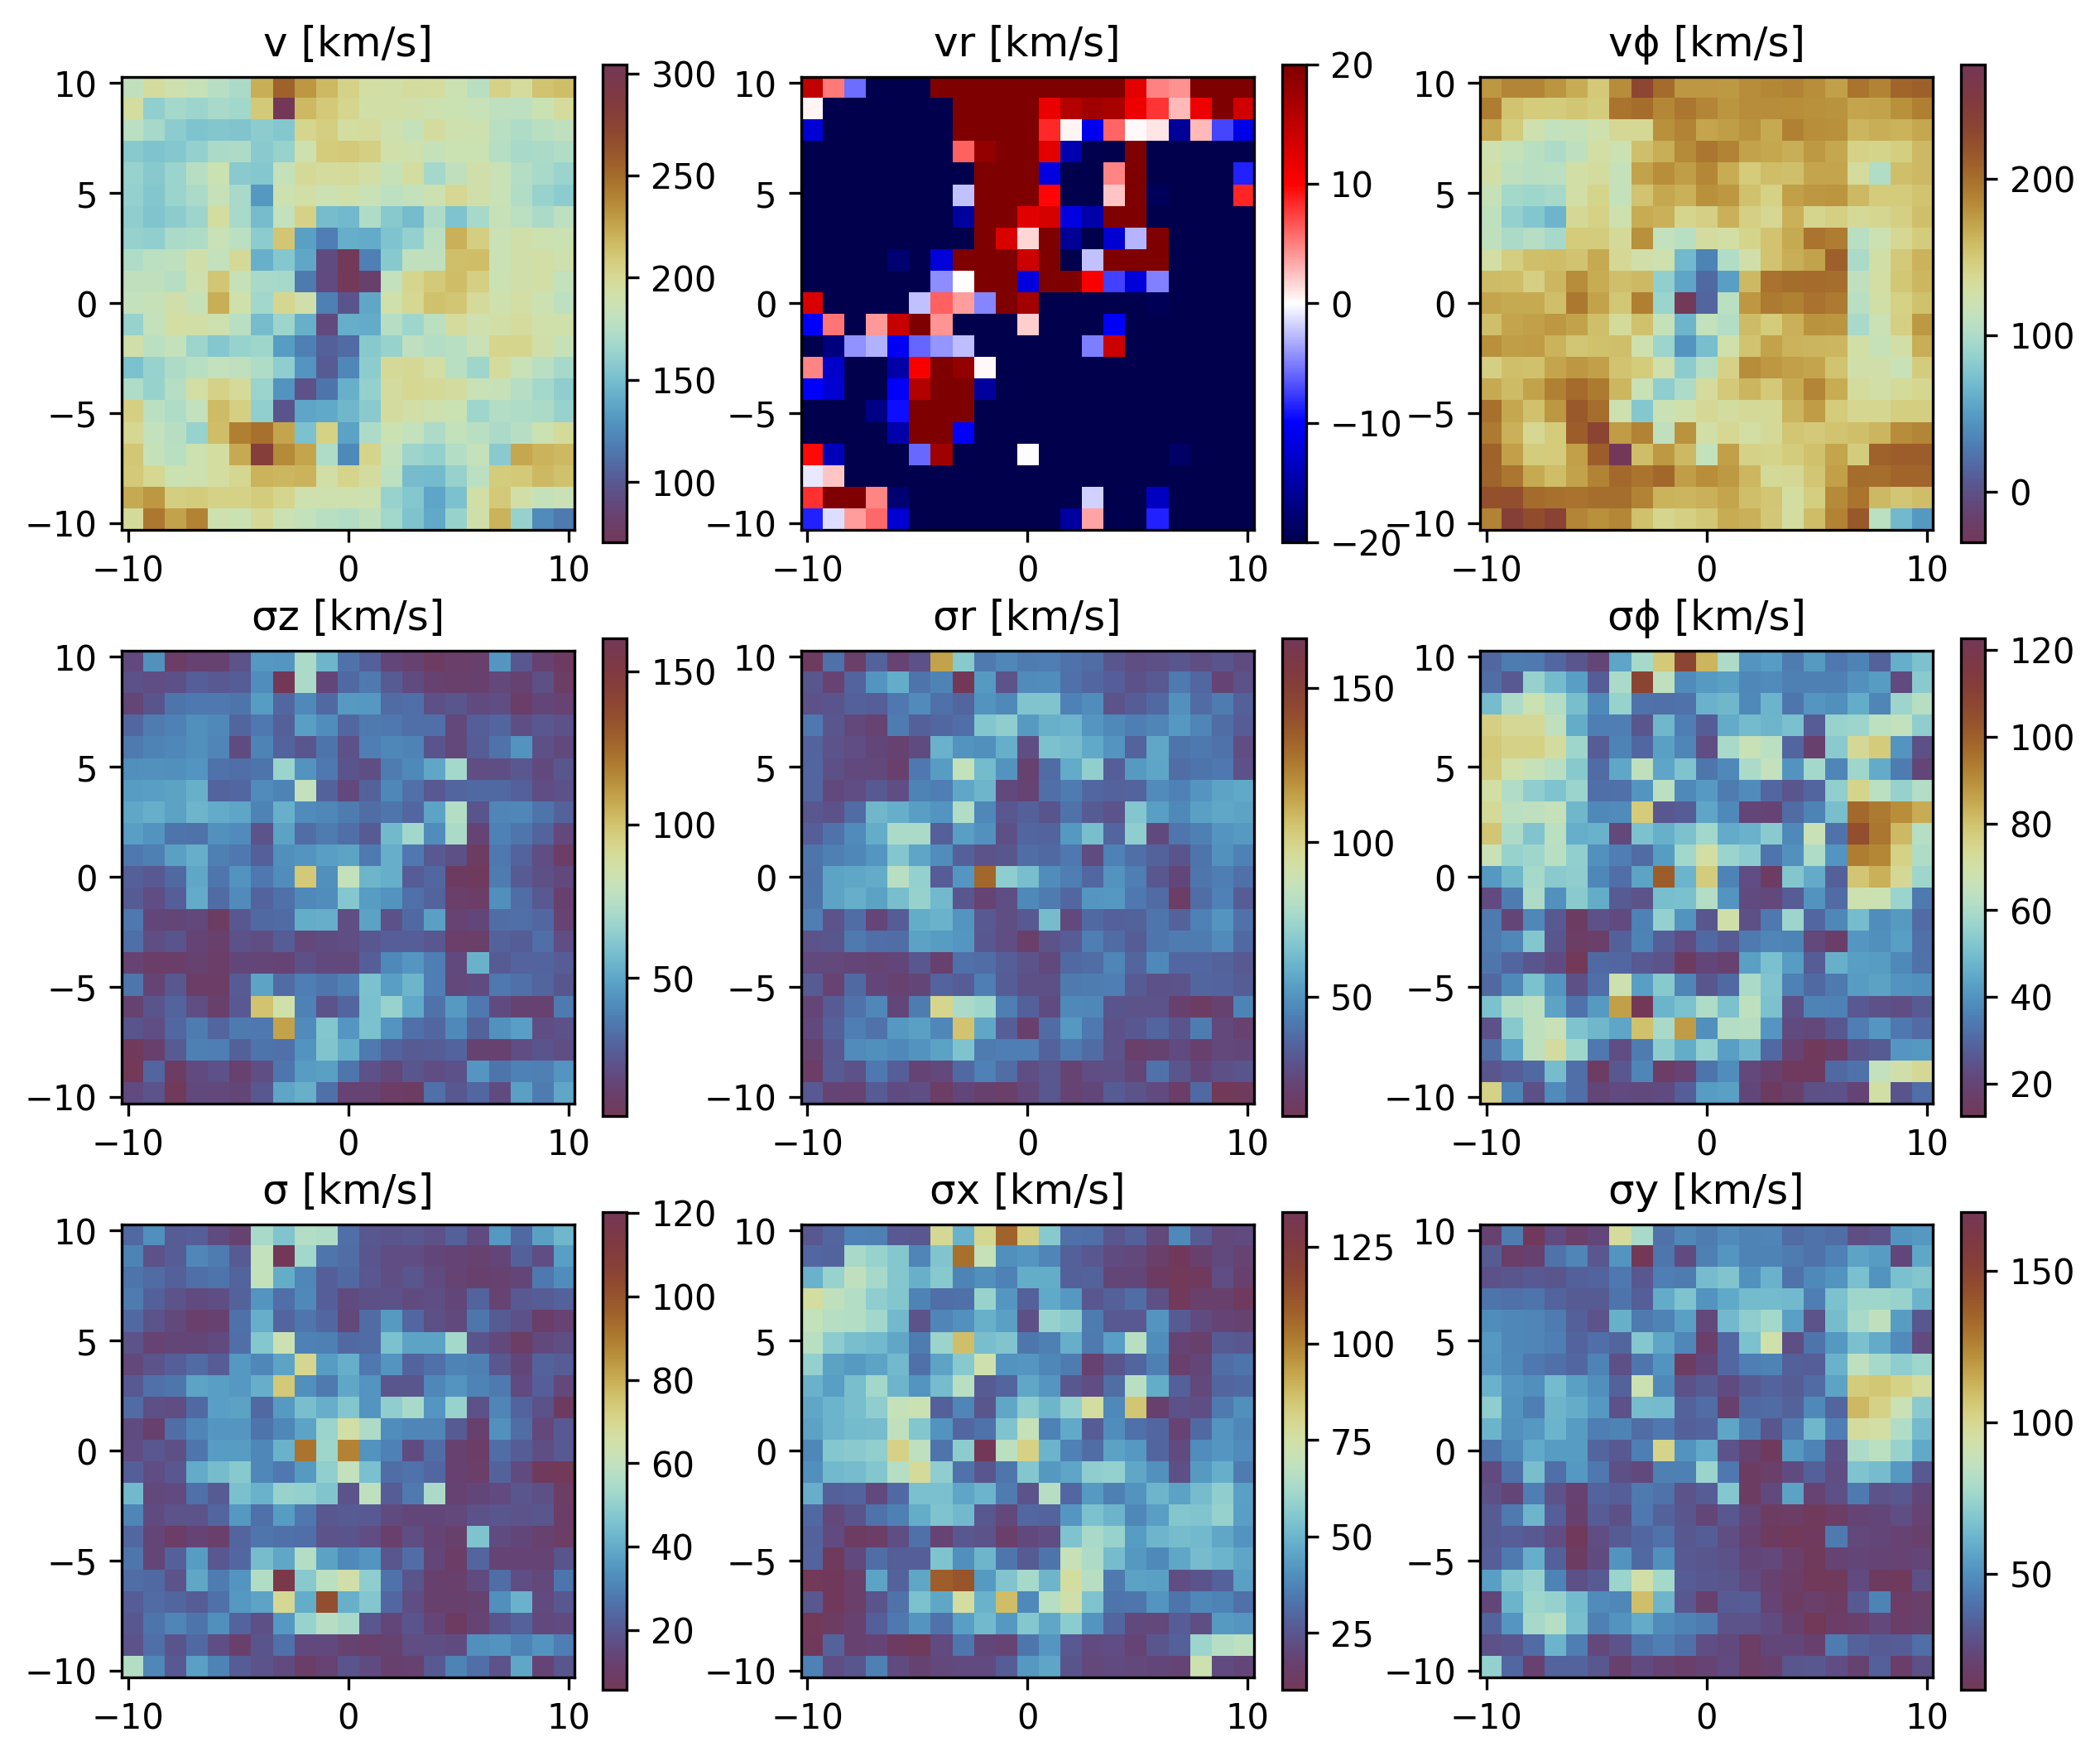

In [43]:
figure(figsize=(10, 8.5))

subplot(3, 3, 1)
title("v [km/s]")
imshow( permutedims(proj_z.maps[:v]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 2)
title("vr [km/s]")
imshow( permutedims(proj_z.maps[:vr_cylinder] ), cmap="seismic", origin="lower", extent=proj_z.cextent, vmin=-20.,vmax=20.)
colorbar()


subplot(3, 3, 3)
title("vϕ [km/s]")
imshow( permutedims(proj_z.maps[:vϕ_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 4)
title("σz [km/s]")
imshow( permutedims(proj_z.maps[:σz] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 5)
title("σr [km/s]")
imshow( permutedims(proj_z.maps[:σr_cylinder]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 6)
title("σϕ [km/s]")
imshow( permutedims(proj_z.maps[:σϕ_cylinder] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 7)
title("σ [km/s]")
imshow( permutedims(proj_z.maps[:σ]) , cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()



subplot(3, 3, 8)
title("σx [km/s]")
imshow( permutedims(proj_z.maps[:σx]  ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar()


subplot(3, 3, 9)
title("σy [km/s]")
imshow( permutedims(proj_z.maps[:σy] ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
colorbar();

## Thermal Properties Analysis

### Sound Speed Projections

Sound speed calculations utilize the adiabatic index γ from hydro files:

**Physical Formula:** cs = √(γ P/ρ) = √(γ kT/μmH)

**Implementation:** 
- Adiabatic index loaded automatically from simulation data
- Temperature and pressure derived from internal energy
- Sound speed represents local gas thermal pressure support

In [44]:
# Sound speed projections in multiple directions
proj_z = projection(gas, :cs, :km_s,           # Z-direction sound speed
                    zrange=[0.45,0.55],        # Thin central slice
                    xrange=[0.4, 0.6], 
                    yrange=[0.4, 0.6])

proj_x = projection(gas, :cs, :km_s,           # X-direction sound speed  
                    zrange=[0.45,0.55],        # Same spatial selection
                    xrange=[0.4, 0.6], 
                    yrange=[0.4, 0.6], 
                    direction=:x);

[Mera]: 2026-07-03T10:12:07.669

domain:
xmin::xmax: 0.4 :: 0.6  	==> 19.2 [kpc] :: 28.8 [kpc]
ymin::ymax: 0.4 :: 0.6  	==> 19.2 [kpc] :: 28.8 [kpc]
zmin::zmax: 0.45 :: 0.55  	==> 21.6 [kpc] :: 26.4 [kpc]

Selected var(s)=(:cs, :sd) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 820 x 820
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 2 (cs, sd)
Processing mode: Variable-based parallel (2 threads)


[Mera]: 2026-07-03T10:12:09.166

domain:
xmin::xmax: 0.4 :: 0.6  	==> 19.2 [kpc] :: 28.8 [kpc]
ymin::ymax: 0.4 :: 0.6  	==> 19.2 [kpc] :: 28.8 [kpc]
zmin::zmax: 0.45 :: 0.55  	==> 21.6 [kpc] :: 26.4 [kpc]

Selected var(s)=(:cs, :sd) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 820 x 410
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 2 (cs, sd)
Processing mode: Variable-based parallel (2 threads)


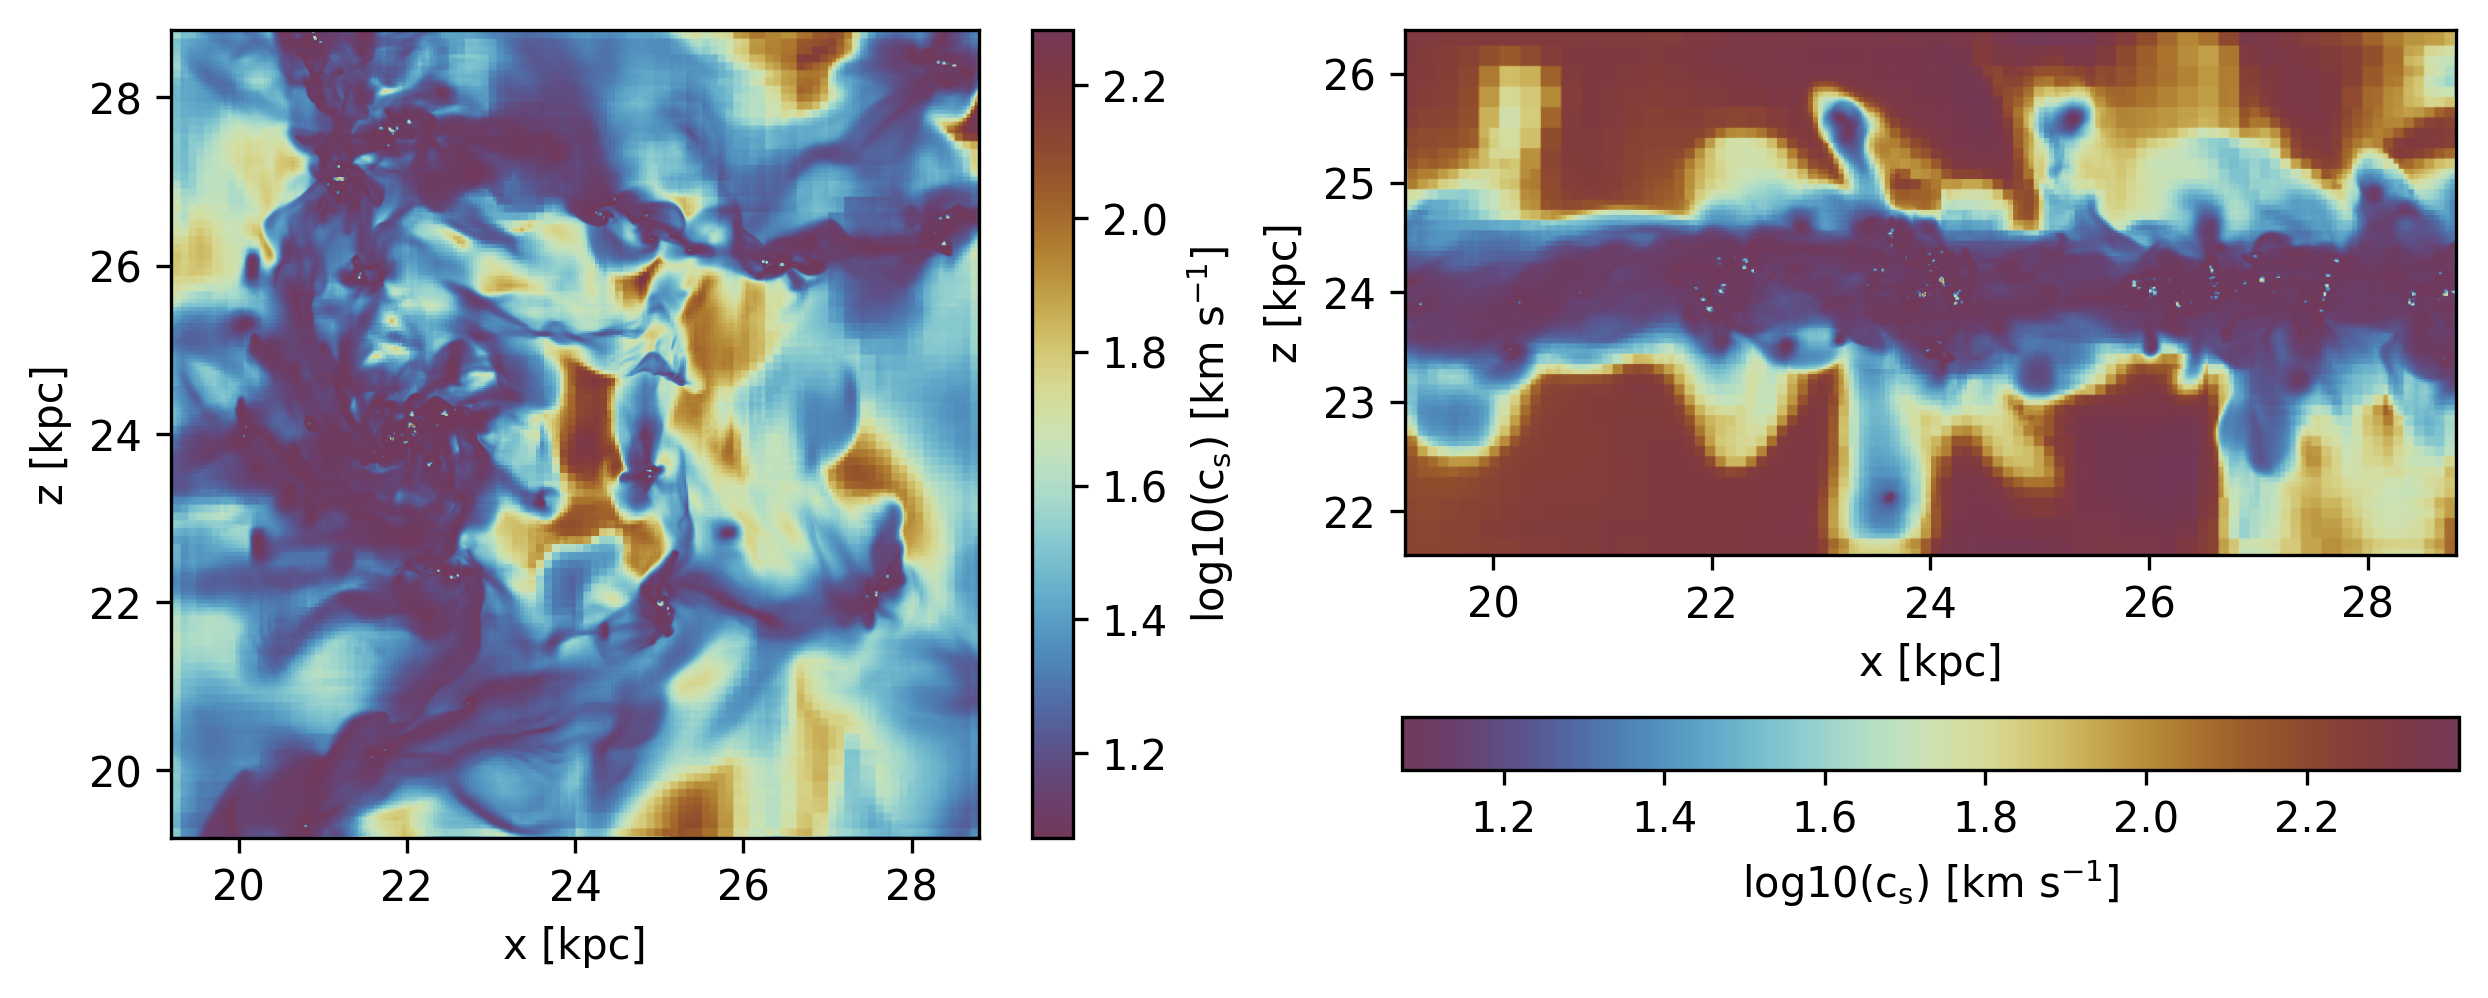

In [45]:
figure(figsize=(10, 3.5))

subplot(1, 2, 1)
im = imshow( log10.(permutedims(proj_z.maps[:cs])   ), cmap=cmap2, origin="lower", extent=proj_z.cextent)
xlabel("x [kpc]")
ylabel("z [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(c_s) \ [km \ s^{-1}]}")


subplot(1, 2, 2)
im = imshow( log10.(permutedims(proj_x.maps[:cs]) ), cmap=cmap2, origin="lower", extent=proj_x.cextent)
xlabel("x [kpc]")
ylabel("z [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(c_s) \ [km \ s^{-1}]}",orientation="horizontal", pad=0.2);


#### Custom Adiabatic Index

Modify the adiabatic index for alternative equation of state calculations:

```julia
gas.info.gamma = 5/3  # Monatomic ideal gas
gas.info.gamma = 7/5  # Diatomic gas
```

#### Practical Examples for Scientific Analysis

##### Star Formation Rate Surface Density
```julia
# Identify dense, cold gas (star-forming regions)
sf_mask = (getvar(gas, :rho, :nH) .> 100) .& 
          (getvar(gas, :Temperature, :K) .< 1000)

sf_proj = projection(gas, :sd, :Msol_pc2, mask=sf_mask,
                    zrange=[-0.5, 0.5], center=[:boxcenter])
```

##### Pressure Support Analysis  
```julia
# Compare thermal vs turbulent pressure support
thermal_proj = projection(gas, :cs, :km_s)
turbulent_proj = projection(gas, :σ, :km_s)

# Thermal pressure ∝ cs²
# Turbulent pressure ∝ σ²
```

##### Rotation Curve Extraction
```julia
# Radial velocity profiles for rotation curves
rotation_proj = projection(gas, [:vr_cylinder, :vϕ_cylinder], [:km_s, :km_s],
                          zrange=[-1, 1],  # Thin disk
                          data_center=[:boxcenter])
```

## Selective Data Analysis

### Masked Projections

Apply physical selection criteria to isolate specific gas phases or conditions. Masking enables targeted analysis of phenomena like star formation regions, shocked gas, or specific temperature/density regimes.

In [46]:
# Create physical condition masks
# Select low-density gas (< 1 particle per cm³)
mask_nH = getvar(gas, :rho, :nH) .< .1     # Number density constraint

# Select ionized gas (> 10⁴ K)  
mask_T = getvar(gas, :Temperature, :K) .> 1e4  # Temperature constraint

# Combine masks: hot AND low-density gas
mask_tot = mask_nH .* mask_T;

#### Apply Masks to Projections

Pass Boolean masks to projection functions to exclude unwanted data:

In [47]:
# Apply mask to projection: only cool, low-density gas
proj_z = projection(gas, :sd, :Msol_pc2, 
                    zrange=[0.45,0.55], 
                    mask=mask_tot)        # Apply combined mask

proj_x = projection(gas, :sd, :Msol_pc2, 
                    zrange=[0.45,0.55], 
                    mask=mask_tot,        # Same mask for consistency
                    direction=:x);

[Mera]: 2026-07-03T10:12:11.839



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.45 :: 0.55  	==> 21.6 [kpc] :: 26.4 [kpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 4096 x 4096
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

:mask provided by function

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


Progress:  29%|███████████▊                             |  ETA: 0:00:05

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:02

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

[Mera]: 2026-07-03T10:12:15.659

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.45 :: 0.55  	==> 21.6 [kpc] :: 26.4 [kpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 4096 x 410
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

:mask provided by function

Available threads: 4


Requested max_threads: 4
Variables: 1 (sd)
Processing mode: Sequential (single thread)


Progress:  29%|███████████▊                             |  ETA: 0:00:03

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:02

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02

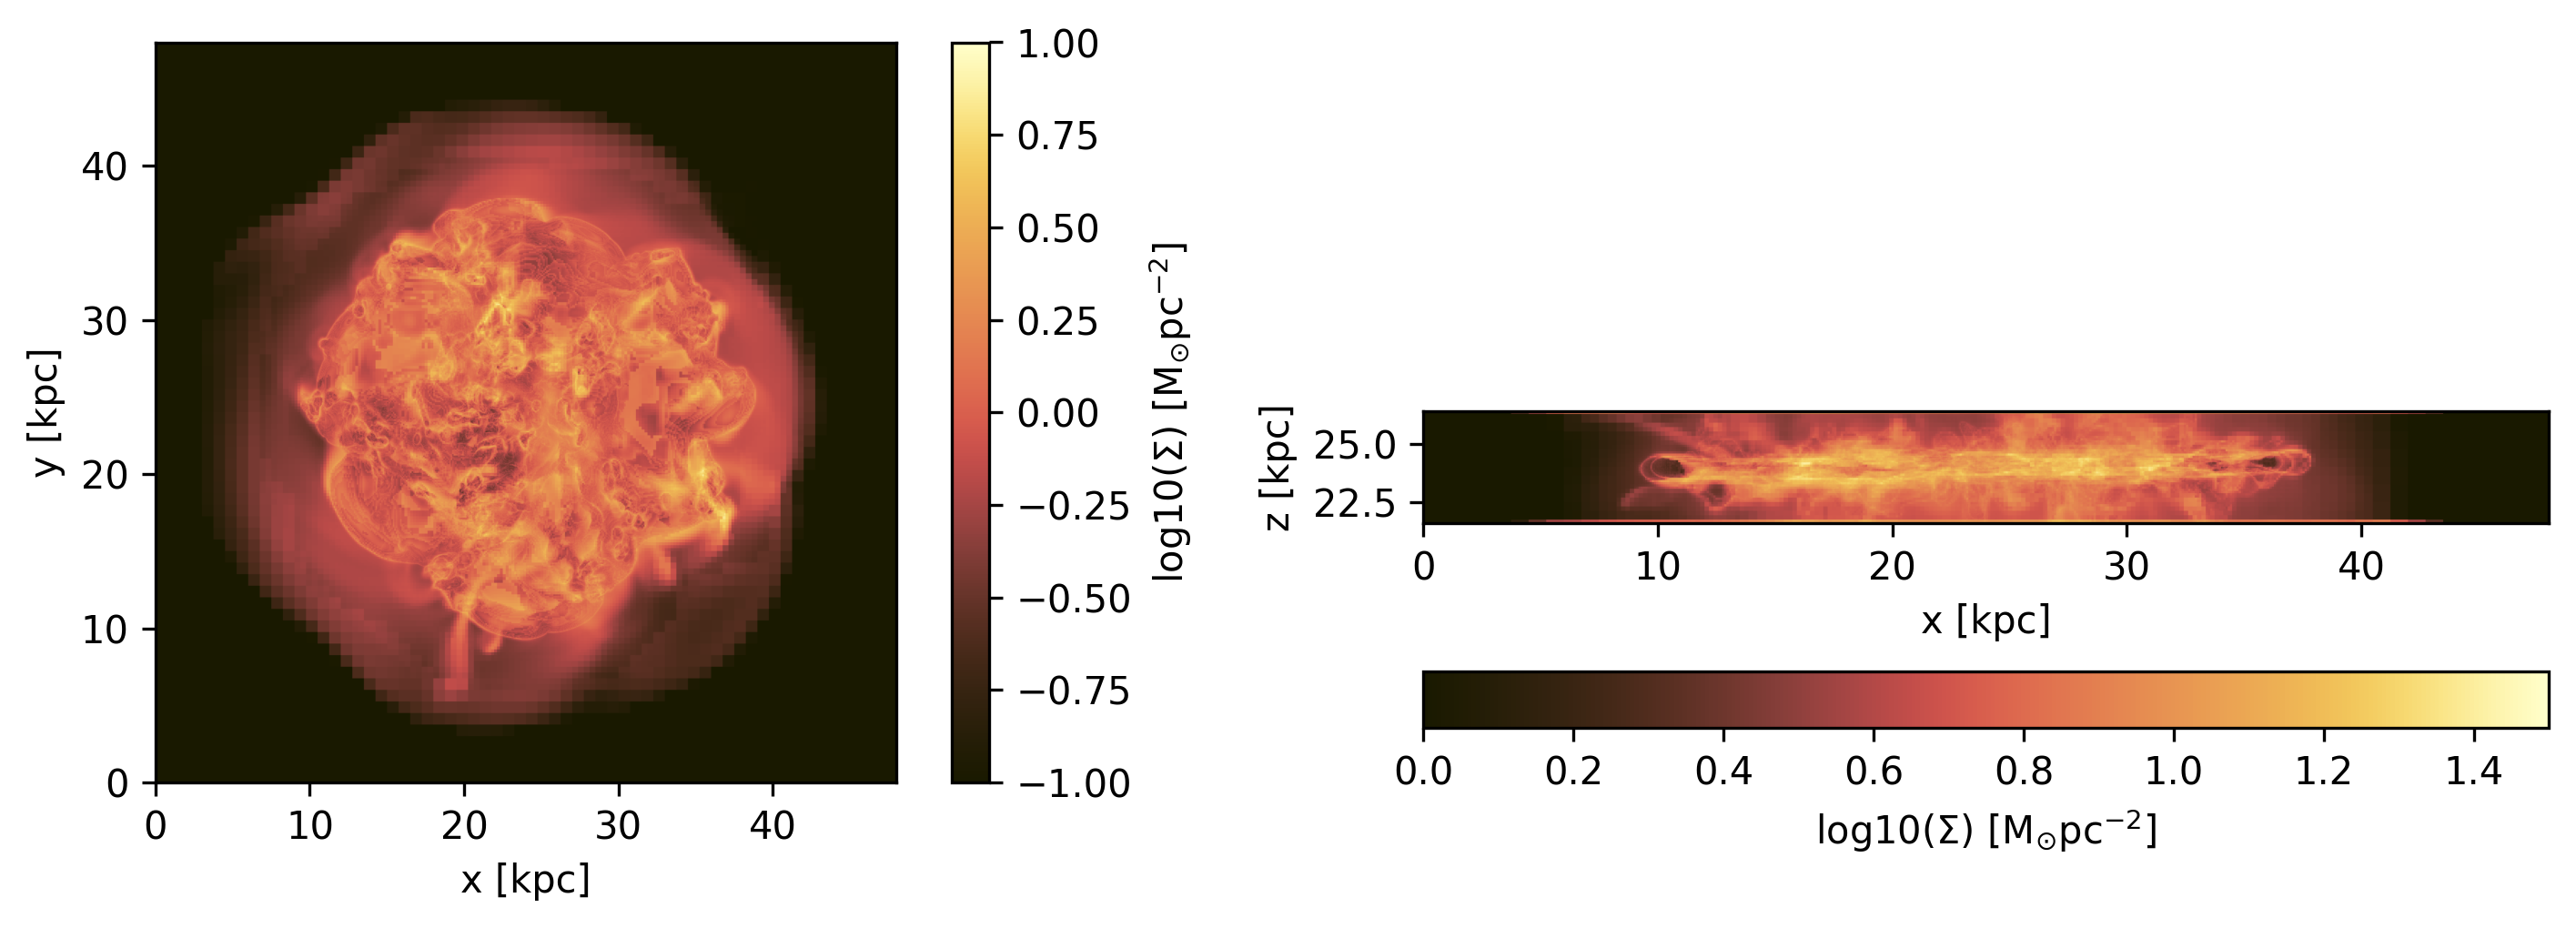

In [48]:
figure(figsize=(10, 3.5))
subplot(1,2,1)
im = imshow( log10.( permutedims(proj_z.maps[:sd])), cmap=cmap, aspect=proj_z.ratio, origin="lower", extent=proj_z.cextent, vmin=-1, vmax=1)
xlabel("x [kpc]")
ylabel("y [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(\Sigma) \ [M_{\odot} pc^{-2}]}")

subplot(1,2,2)
im = imshow( log10.( permutedims(proj_x.maps[:sd])), cmap=cmap, origin="lower", extent=proj_x.cextent, vmin=0, vmax=1.5)
xlabel("x [kpc]")
ylabel("z [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(\Sigma) \ [M_{\odot} pc^{-2}]}",orientation="horizontal", pad=0.2);
tight_layout()

## Weighting and Integration Schemes

### Alternative Weighting Methods

Customize projection weighting to emphasize different physical aspects:

In [49]:
# Volume-weighted projection (alternative to mass-weighted default)
proj_z = projection(gas, :cs, :km_s, 
                    weighting=[:volume]);  # Volume weighting instead of mass

[Mera]: 2026-07-03T10:12:21.308



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]

Selected var(s)=(:cs,) 
Weighting      = :volume

Effective resolution: 4096^2
Map size: 4096 x 4096
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (cs)
Processing mode: Sequential (single thread)


Progress:  29%|███████████▊                             |  ETA: 0:00:38

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:12

Progress: 100%|█████████████████████████████████████████| Time: 0:00:17

#### Custom Weighting with Units

Use any predefined quantity as weighting with specified units:

In [50]:
# Volume-weighted with explicit units
proj_z = projection(gas, :cs, :km_s, 
                    weighting=[:volume, :cm3]);  # Volume in cm³ units

[Mera]: 2026-07-03T10:12:59.911

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]

Selected var(s)=(:cs,) 
Weighting      = :volume

Effective resolution: 4096^2
Map size: 4096 x 4096
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 1 (cs)
Processing mode: Sequential (single thread)


Progress:  29%|███████████▊                             |  ETA: 0:00:38

Progress:  57%|███████████████████████▍                 |  ETA: 0:00:12

Progress: 100%|█████████████████████████████████████████| Time: 0:00:17

## Specialized Applications

### Ultra-Thin Slice Analysis

Create quasi-2D cuts through 3D data using extremely narrow projection ranges:

In [51]:
# Ultra-thin slice: effectively 2D cut through 3D data
proj_y = projection(gas, [:sd, :v], [:Msol_pc2, :km_s], 
                    yrange=[0.0001,0.0001],   # Extremely narrow range (0.1 pc)
                    center=[:bc], 
                    range_unit=:kpc, 
                    direction=:y)  ;           # Y-direction slice

[Mera]: 2026-07-03T10:13:39.883



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]
ymin::ymax: 0.5000021 :: 0.5000021  	==> 24.0 [kpc] :: 24.0 [kpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 48.0 [kpc]

Selected var(s)=(:sd, :v) 
Weighting      = :mass

Effective resolution: 4096^2
Map size: 4096 x 4096
Pixel size: 11.719 [pc]
Simulation min.: 11.719 [pc]

Available threads: 4


Requested max_threads: 4
Variables: 2 (sd, v)
Processing mode: Variable-based parallel (2 threads)


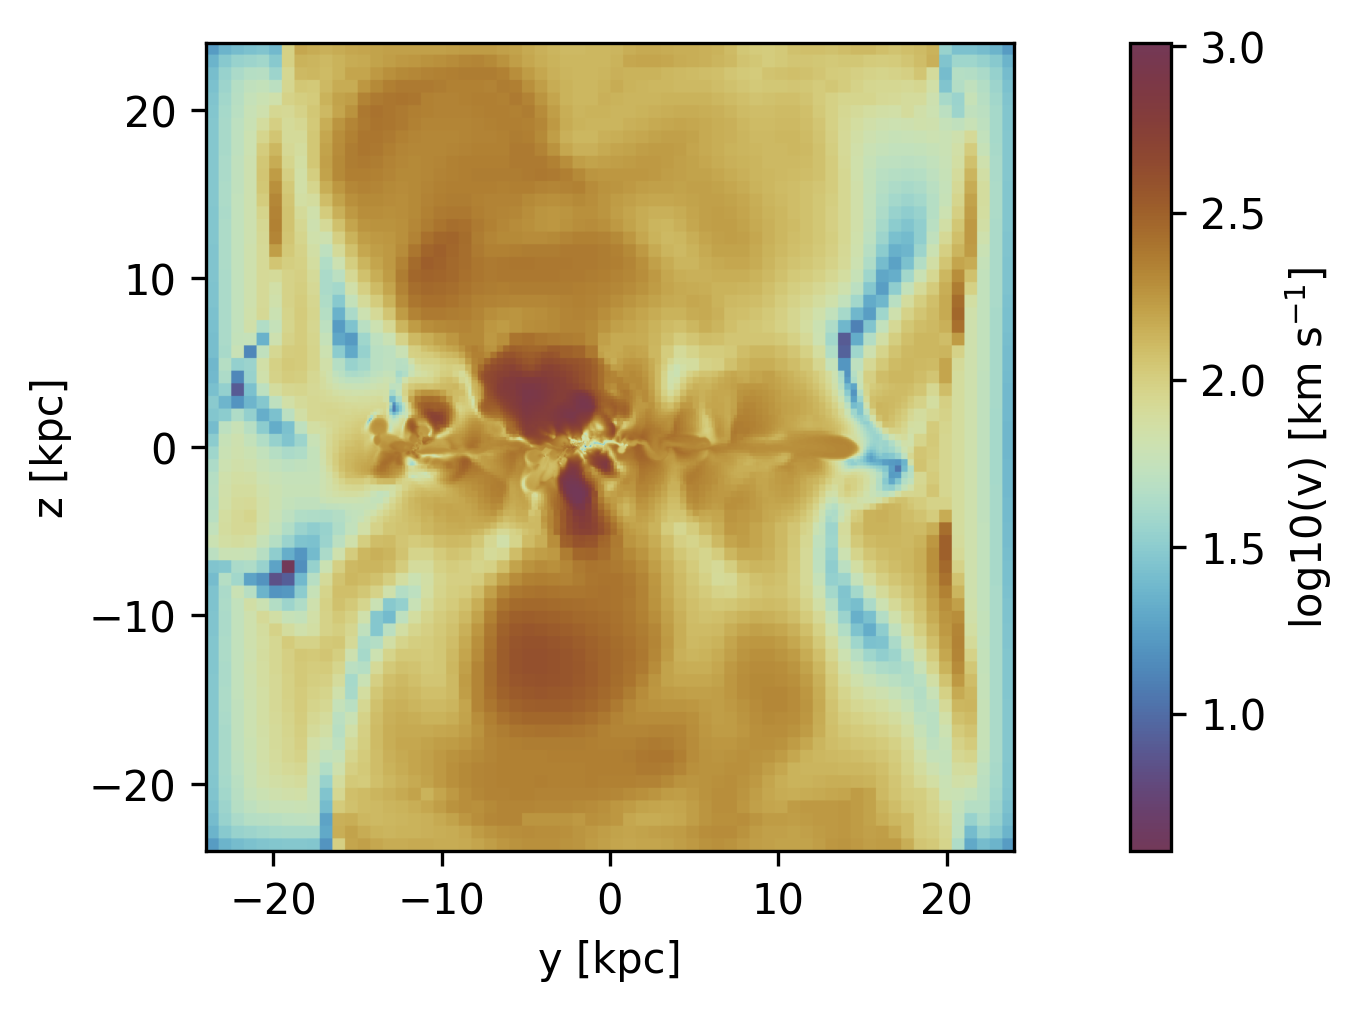

In [52]:
# Visualize ultra-thin slice velocity field
figure(figsize=(10, 3.5))
im = imshow(log10.(permutedims(proj_y.maps[:v])), 
           cmap=cmap2, 
           origin="lower", 
           extent=proj_y.cextent)
xlabel("y [kpc]")
ylabel("z [kpc]")
cb = colorbar(im, label=L"\mathrm{log10(v) \ [km \ s^{-1}]}");

# Note: Ultra-thin slices provide all cells that intersect the 2D plane

## Summary

This tutorial covered the comprehensive projection capabilities of MERA.jl for hydrodynamical data analysis. You've learned how to:

### Core Functionality
- **Create basic projections** with `projection(data, :variable, :unit)`
- **Control projection directions** (x, y, z) for different viewing angles
- **Select spatial regions** using `xrange`, `yrange`, `zrange` parameters
- **Access projection results** through the structured output object

### Advanced Techniques
- **Multi-quantity projections** for efficient batch processing
- **Cylindrical coordinate analysis** for galactic disk studies
- **Resolution control** via `lmax`, `res`, and `pxsize` parameters
- **Masking and filtering** for targeted physical analysis
- **Custom weighting schemes** beyond default mass-weighting
